# Sati Clip Training Pipeline

IMU-only MVP training notebook for Sati Clip.

Models:
1. Posture / movement risk classifier using windowed IMU features.
2. Gaussian IMU-based movement degradation / fatigue proxy model using fresh_baseline windows only.

Hardware assumptions for this training version:
- Upper back IMU: Arduino UNO Q + Modulino IMU, no magnetometer.
- Lower back / pelvis IMU: Arduino Nano IMU, optional lower magnetometer columns.
- No distance sensor in this training version.

Important: this model is an IMU-based movement degradation / fatigue proxy. It is not a medical muscle-fatigue diagnosis, and it does not rely only on tremor or 8-12 Hz FFT energy.

## Cloud Runtime Setup

Put CSV files under `data/raw/` in the runtime. The loader searches recursively, so nested folders are fine.

If you use Colab, upload a zipped `data/raw` folder or mount Drive and set `CONFIG.data_dir` in the next config cell.

In [48]:
# Cloud runtimes usually already include these, but this cell is safe to run in Colab/Kaggle.
# %pip install -q pandas numpy scipy scikit-learn joblib matplotlib

In [49]:
from __future__ import annotations

import json
import math
import warnings
from dataclasses import dataclass
from pathlib import Path
from typing import Callable, Dict, List, Optional, Tuple

import joblib
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.fft import rfft, rfftfreq
from scipy.signal import butter, filtfilt
from sklearn.covariance import EmpiricalCovariance
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score, log_loss
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", 120)
plt.rcParams["figure.dpi"] = 120

In [50]:
@dataclass
class PipelineConfig:
    data_dir: str = "data/raw"
    output_dir: str = "artifacts"
    sampling_hz: int = 50

    # Posture model window: 1.5 seconds, 50% overlap.
    posture_window_sec: float = 1.5
    posture_overlap: float = 0.5

    # Movement degradation proxy window: 4 seconds, 50% overlap for stability/FFT features.
    fatigue_window_sec: float = 4.0
    fatigue_overlap: float = 0.5

    # Feature-level jitter target for train set only.
    augment_target_per_class: int = 300
    augment_noise_scale: float = 0.03

    random_state: int = 42

    # RandomForest is not epoch-based, so we plot validation loss/F1 by tree count.
    rf_curve_estimators: tuple[int, ...] = (10, 25, 50, 100, 200)

    # Optional preprocessing experiment.
    filter_order: int = 4
    posture_acc_lowpass_hz: float = 12.0
    posture_gyro_lowpass_hz: float = 15.0
    movement_degradation_highpass_hz: float = 0.5

    # Squared Mahalanobis threshold. Tune using validation data and RPE/session phase summaries.
    movement_degradation_anomaly_threshold: float = 12.0


CONFIG = PipelineConfig()
Path(CONFIG.output_dir).mkdir(parents=True, exist_ok=True)
CONFIG

PipelineConfig(data_dir='data/raw', output_dir='artifacts', sampling_hz=50, posture_window_sec=1.5, posture_overlap=0.5, fatigue_window_sec=4.0, fatigue_overlap=0.5, augment_target_per_class=300, augment_noise_scale=0.03, random_state=42, rf_curve_estimators=(10, 25, 50, 100, 200), filter_order=4, posture_acc_lowpass_hz=12.0, posture_gyro_lowpass_hz=15.0, movement_degradation_highpass_hz=0.5, movement_degradation_anomaly_threshold=12.0)

In [51]:
META_COLUMNS = [
    "trial_id", "subject_id", "timestamp_ms", "label", "risk_label",
    "session_phase", "rpe", "load_level", "label_quality",
]

# Optional metadata only. MVP v1 does not predict motion_phase as a target label.
MOTION_PHASE_COLUMN = "motion_phase"
MOTION_PHASE_VALUES = [
    "idle",
    "prepare_descend",
    "lift_up",
    "hold_still",
    "carry_walk",
    "place_down",
    "return_stand",
    "unknown",
]
OPTIONAL_META_COLUMNS = [MOTION_PHASE_COLUMN]

RAW_IMU_COLUMNS = [
    "acc_up_x", "acc_up_y", "acc_up_z",
    "gyro_up_x", "gyro_up_y", "gyro_up_z",
    "acc_low_x", "acc_low_y", "acc_low_z",
    "gyro_low_x", "gyro_low_y", "gyro_low_z",
]

# Upper UNO Q + Modulino IMU has no magnetometer. Only lower magnetometer is optional.
MAG_LOW_COLUMNS = ["mag_low_x", "mag_low_y", "mag_low_z"]
ORIENTATION_COLUMNS = ["pitch_up", "roll_up", "yaw_up", "pitch_low", "roll_low", "yaw_low"]
BIOMECH_ORIENTATION_COLUMNS = ["pitch_up", "roll_up", "pitch_low", "roll_low"]

REQUIRED_COLUMNS = META_COLUMNS + RAW_IMU_COLUMNS
OPTIONAL_COLUMNS = OPTIONAL_META_COLUMNS + MAG_LOW_COLUMNS + ORIENTATION_COLUMNS

TRAIN_CLASS_MAP = {
    "safe_lift_motion": "safe_lift",
    "unsafe_flexion_motion": "stoop_risk",
    "unsafe_twist_motion": "twist_risk",
    "bend_no_load": "non_risk_bend",
    "sit_bend": "non_risk_bend",
    "walk": "normal_activity",
    "sit": "normal_activity",
    "transit_noise": "transit_ignore",
}

MOVEMENT_DEGRADATION_EVAL_PHASES = ["fresh_baseline", "repeated_task", "fatigue_like"]
FATIGUE_PHASES = MOVEMENT_DEGRADATION_EVAL_PHASES + ["recovery"]  # kept for older notebook cells; not a medical label

In [52]:
def ensure_dir(path: str | Path) -> None:
    Path(path).mkdir(parents=True, exist_ok=True)


def validate_required_columns(df: pd.DataFrame, source_name: str) -> None:
    missing = [col for col in REQUIRED_COLUMNS if col not in df.columns]
    if missing:
        raise ValueError(
            f"{source_name} is missing required columns: {missing}. "
            "motion_phase, orientation, and lower magnetometer columns are optional."
        )


def warn_missing_optional_columns(df: pd.DataFrame, source_name: str) -> None:
    missing = [col for col in OPTIONAL_COLUMNS if col not in df.columns]
    if missing:
        warnings.warn(
            f"{source_name} is missing optional columns: {missing}. "
            "Dependent features/metadata will be skipped or filled safely.",
            stacklevel=2,
        )


def safe_numeric(df: pd.DataFrame, columns: List[str]) -> pd.DataFrame:
    df = df.copy()
    for col in columns:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    return df


def normalize_motion_phase(series: pd.Series) -> pd.Series:
    normalized = series.fillna("unknown").astype(str).str.strip().str.lower()
    return normalized.where(normalized.isin(MOTION_PHASE_VALUES), "unknown")


def majority_value(series: pd.Series, default: str = "unknown") -> tuple[str, float]:
    clean = series.fillna(default).astype(str)
    if clean.empty:
        return default, 0.0
    counts = clean.value_counts(dropna=False)
    value = str(counts.index[0])
    purity = float(counts.iloc[0] / len(clean))
    return value, purity


def as_numeric_array(df: pd.DataFrame, col: str) -> np.ndarray:
    return pd.to_numeric(df[col], errors="coerce").to_numpy(dtype=float)


def finite_or_zero(values: np.ndarray) -> np.ndarray:
    return np.nan_to_num(np.asarray(values, dtype=float), nan=0.0, posinf=0.0, neginf=0.0)


def safe_stat(values: np.ndarray, stat: str) -> float:
    x = np.asarray(values, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return 0.0
    if stat == "mean":
        return float(np.mean(x))
    if stat == "std":
        return float(np.std(x))
    if stat == "min":
        return float(np.min(x))
    if stat == "max":
        return float(np.max(x))
    if stat == "var":
        return float(np.var(x))
    if stat == "rms":
        return float(np.sqrt(np.mean(x ** 2)))
    raise ValueError(f"Unsupported stat: {stat}")


def acc_mag(df: pd.DataFrame, prefix: str) -> np.ndarray:
    cols = [f"acc_{prefix}_x", f"acc_{prefix}_y", f"acc_{prefix}_z"]
    if not all(c in df.columns for c in cols):
        raise ValueError(f"Missing accelerometer columns for prefix={prefix}: {cols}")
    return np.sqrt(sum(finite_or_zero(as_numeric_array(df, c)) ** 2 for c in cols))


def gyro_mag(df: pd.DataFrame, prefix: str) -> np.ndarray:
    cols = [f"gyro_{prefix}_x", f"gyro_{prefix}_y", f"gyro_{prefix}_z"]
    if not all(c in df.columns for c in cols):
        raise ValueError(f"Missing gyroscope columns for prefix={prefix}: {cols}")
    return np.sqrt(sum(finite_or_zero(as_numeric_array(df, c)) ** 2 for c in cols))


def jerk(signal: np.ndarray, sampling_hz: int) -> np.ndarray:
    signal = finite_or_zero(signal)
    if len(signal) < 2:
        return np.array([0.0])
    return np.diff(signal) * sampling_hz


def band_energy(signal: np.ndarray, sampling_hz: int, low_hz: float, high_hz: float) -> float:
    signal = finite_or_zero(signal)
    signal = signal - np.mean(signal)
    if len(signal) < 4:
        return 0.0
    yf = np.abs(rfft(signal)) ** 2
    xf = rfftfreq(len(signal), d=1.0 / sampling_hz)
    band = (xf >= low_hz) & (xf <= high_hz)
    return float(np.sum(yf[band]))


def spectral_entropy(signal: np.ndarray, sampling_hz: int) -> float:
    signal = finite_or_zero(signal)
    signal = signal - np.mean(signal)
    if len(signal) < 4:
        return 0.0
    power = np.abs(rfft(signal)) ** 2
    power_sum = np.sum(power)
    if power_sum <= 1e-12:
        return 0.0
    p = power / power_sum
    p = p[p > 1e-12]
    return float(-np.sum(p * np.log(p)) / np.log(len(power)))


def pearson_corr_safe(a: np.ndarray, b: np.ndarray) -> float:
    a = finite_or_zero(a)
    b = finite_or_zero(b)
    if len(a) < 3 or len(b) < 3:
        return 0.0
    if np.std(a) < 1e-9 or np.std(b) < 1e-9:
        return 0.0
    return float(np.corrcoef(a, b)[0, 1])


def has_usable_biomech_orientation(window_df: pd.DataFrame) -> bool:
    if not all(c in window_df.columns for c in BIOMECH_ORIENTATION_COLUMNS):
        return False
    return all(np.isfinite(as_numeric_array(window_df, col)).any() for col in BIOMECH_ORIENTATION_COLUMNS)


def feature_columns(df: pd.DataFrame, extra_meta_cols: Optional[set[str]] = None) -> List[str]:
    meta_cols = {
        "trial_id", "subject_id", "label", "risk_label", "session_phase", "rpe",
        "load_level", "label_quality", "motion_phase", "motion_phase_purity",
        "window_start_ms", "window_end_ms",
    }
    if extra_meta_cols:
        meta_cols.update(extra_meta_cols)
    return [c for c in df.columns if c not in meta_cols and pd.api.types.is_numeric_dtype(df[c])]


def clean_feature_values(df: pd.DataFrame, feat_cols: List[str]) -> pd.DataFrame:
    cleaned = df.copy()
    if feat_cols:
        cleaned[feat_cols] = cleaned[feat_cols].replace([np.inf, -np.inf], np.nan).fillna(0.0)
    return cleaned


def butter_filter_signal(
    values: np.ndarray,
    sampling_hz: int,
    cutoff_hz: float,
    filter_type: str,
    order: int = 4,
) -> np.ndarray:
    """Zero-phase Butterworth filter with short-window fallback."""
    x = finite_or_zero(values)
    nyquist = 0.5 * sampling_hz
    if cutoff_hz <= 0 or cutoff_hz >= nyquist:
        return x
    normal_cutoff = cutoff_hz / nyquist
    b, a = butter(order, normal_cutoff, btype=filter_type)
    padlen = 3 * max(len(a), len(b))
    if len(x) <= padlen:
        return x
    try:
        return filtfilt(b, a, x)
    except ValueError:
        return x


def filter_window_for_posture(window_df: pd.DataFrame, sampling_hz: int) -> pd.DataFrame:
    """Low-pass accel/gyro signals for posture features."""
    filtered = window_df.copy()
    for col in [c for c in RAW_IMU_COLUMNS if c.startswith("acc_")]:
        filtered[col] = butter_filter_signal(
            as_numeric_array(window_df, col),
            sampling_hz=sampling_hz,
            cutoff_hz=CONFIG.posture_acc_lowpass_hz,
            filter_type="lowpass",
            order=CONFIG.filter_order,
        )
    for col in [c for c in RAW_IMU_COLUMNS if c.startswith("gyro_")]:
        filtered[col] = butter_filter_signal(
            as_numeric_array(window_df, col),
            sampling_hz=sampling_hz,
            cutoff_hz=CONFIG.posture_gyro_lowpass_hz,
            filter_type="lowpass",
            order=CONFIG.filter_order,
        )
    return filtered


def filter_window_for_fatigue(window_df: pd.DataFrame, sampling_hz: int) -> pd.DataFrame:
    """High-pass raw IMU channels to remove slow drift before fatigue FFT features."""
    filtered = window_df.copy()
    for col in RAW_IMU_COLUMNS:
        filtered[col] = butter_filter_signal(
            as_numeric_array(window_df, col),
            sampling_hz=sampling_hz,
            cutoff_hz=CONFIG.movement_degradation_highpass_hz,
            filter_type="highpass",
            order=CONFIG.filter_order,
        )
    return filtered


In [53]:
def load_csv_folder(data_dir: str | Path) -> pd.DataFrame:
    data_dir = Path(data_dir)
    files = sorted(data_dir.rglob("*.csv"))
    if not files:
        raise FileNotFoundError(f"No CSV files found under: {data_dir.resolve()}")

    dfs = []
    for path in files:
        df = pd.read_csv(path)
        validate_required_columns(df, str(path))
        warn_missing_optional_columns(df, str(path))
        df["source_file"] = str(path)
        dfs.append(df)

    data = pd.concat(dfs, ignore_index=True)
    numeric_cols = ["timestamp_ms", "rpe", *RAW_IMU_COLUMNS, *MAG_LOW_COLUMNS, *ORIENTATION_COLUMNS]
    data = safe_numeric(data, numeric_cols)

    data["label_quality"] = data["label_quality"].fillna("unknown")
    data["session_phase"] = data["session_phase"].fillna("unknown")
    data["label"] = data["label"].fillna("unknown")

    # motion_phase is optional metadata for EDA/filtering/reporting, not a target label in MVP v1.
    if MOTION_PHASE_COLUMN not in data.columns:
        data[MOTION_PHASE_COLUMN] = "unknown"
    data[MOTION_PHASE_COLUMN] = normalize_motion_phase(data[MOTION_PHASE_COLUMN])
    return data


def run_eda(data: pd.DataFrame, output_dir: str | Path) -> dict:
    ensure_dir(output_dir)
    output_dir = Path(output_dir)

    summary = {
        "num_rows": int(len(data)),
        "num_trials": int(data["trial_id"].nunique()),
        "num_subjects": int(data["subject_id"].nunique()),
        "labels": data["label"].value_counts(dropna=False).to_dict(),
        "risk_labels": data["risk_label"].value_counts(dropna=False).to_dict(),
        "session_phase": data["session_phase"].value_counts(dropna=False).to_dict(),
        "motion_phase": data[MOTION_PHASE_COLUMN].value_counts(dropna=False).to_dict(),
        "label_quality": data["label_quality"].value_counts(dropna=False).to_dict(),
        "missing_rate_top30": data.isna().mean().sort_values(ascending=False).head(30).to_dict(),
    }

    with open(output_dir / "eda_summary.json", "w", encoding="utf-8") as f:
        json.dump(summary, f, ensure_ascii=False, indent=2)

    rows = []
    for trial_id, g in data.groupby("trial_id", dropna=False):
        valid_ts = g["timestamp_ms"].dropna()
        if len(valid_ts) >= 2:
            duration_s = max((valid_ts.max() - valid_ts.min()) / 1000.0, 1e-9)
            approx_hz = max(len(valid_ts) - 1, 1) / duration_s
        else:
            duration_s = np.nan
            approx_hz = np.nan
        rows.append({
            "trial_id": trial_id,
            "subject_id": g["subject_id"].iloc[0],
            "label": g["label"].iloc[0],
            "motion_phase": majority_value(g[MOTION_PHASE_COLUMN])[0],
            "motion_phase_purity": majority_value(g[MOTION_PHASE_COLUMN])[1],
            "rows": int(len(g)),
            "duration_s": duration_s,
            "approx_hz": approx_hz,
            "source_file": g["source_file"].iloc[0],
        })

    eda_trials = pd.DataFrame(rows)
    eda_trials.to_csv(output_dir / "eda_trials.csv", index=False)

    print(f"Rows: {summary['num_rows']:,}")
    print(f"Trials: {summary['num_trials']:,}")
    print(f"Subjects: {summary['num_subjects']:,}")
    print(f"Saved EDA to {output_dir}")
    return summary

## EDA Plot Helpers

These functions run before model training. They check missingness, row counts, trial sampling rate, posture-class balance, and movement-degradation spectral/supporting structure.


In [54]:
def _save_and_display(fig, path: str | Path) -> None:
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.tight_layout()
    fig.savefig(path, dpi=160, bbox_inches="tight")
    display(fig)
    plt.close(fig)


def compute_trial_stats(data: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for trial_id, g in data.groupby("trial_id", dropna=False):
        valid_ts = g["timestamp_ms"].dropna()
        if len(valid_ts) >= 2:
            duration_s = max((valid_ts.max() - valid_ts.min()) / 1000.0, 1e-9)
            approx_hz = max(len(valid_ts) - 1, 1) / duration_s
        else:
            duration_s = np.nan
            approx_hz = np.nan
        rows.append({
            "trial_id": trial_id,
            "subject_id": g["subject_id"].iloc[0],
            "label": g["label"].iloc[0],
            "session_phase": g["session_phase"].iloc[0],
            "motion_phase": majority_value(g[MOTION_PHASE_COLUMN])[0],
            "motion_phase_purity": majority_value(g[MOTION_PHASE_COLUMN])[1],
            "label_quality": g["label_quality"].iloc[0],
            "rows": int(len(g)),
            "duration_s": duration_s,
            "approx_hz": approx_hz,
            "source_file": g["source_file"].iloc[0] if "source_file" in g.columns else "unknown",
        })
    return pd.DataFrame(rows)


def plot_count_bar(counts: pd.Series, title: str, path: str | Path, top_n: int = 30) -> None:
    counts = counts.head(top_n).sort_values()
    height = max(3.5, 0.35 * len(counts) + 1.5)
    fig, ax = plt.subplots(figsize=(8, height))
    counts.plot(kind="barh", ax=ax, color="#2f80ed")
    ax.set_title(title)
    ax.set_xlabel("count")
    ax.set_ylabel("")
    _save_and_display(fig, path)


def plot_raw_data_eda(data: pd.DataFrame, output_dir: str | Path) -> Dict[str, pd.DataFrame]:
    output_dir = Path(output_dir)
    eda_dir = output_dir / "eda_plots"
    ensure_dir(eda_dir)

    missing_df = pd.DataFrame({
        "column": data.columns,
        "null_count": data.isna().sum().to_numpy(),
        "null_pct": (100 * data.isna().mean()).to_numpy(),
        "dtype": [str(data[c].dtype) for c in data.columns],
    }).sort_values(["null_count", "column"], ascending=[False, True])
    missing_df.to_csv(output_dir / "eda_missingness.csv", index=False)

    display(missing_df.head(40))
    nonzero_missing = missing_df[missing_df["null_count"] > 0].head(30)
    if nonzero_missing.empty:
        print("No null values found.")
    else:
        fig, ax = plt.subplots(figsize=(9, max(4, 0.35 * len(nonzero_missing))))
        ax.barh(nonzero_missing["column"][::-1], nonzero_missing["null_count"][::-1], color="#eb5757")
        ax.set_title("Null count by column")
        ax.set_xlabel("null count")
        _save_and_display(fig, eda_dir / "null_counts.png")

    trial_stats = compute_trial_stats(data)
    trial_stats.to_csv(output_dir / "eda_trials.csv", index=False)
    display(trial_stats.describe(include="all"))

    plot_count_bar(data["label"].value_counts(), "Datapoints by raw label", eda_dir / "datapoints_by_label.png")
    plot_count_bar(data["session_phase"].value_counts(), "Datapoints by session phase", eda_dir / "datapoints_by_session_phase.png")
    plot_count_bar(data[MOTION_PHASE_COLUMN].value_counts(), "Datapoints by motion phase", eda_dir / "datapoints_by_motion_phase.png")
    plot_count_bar(data["label_quality"].value_counts(), "Datapoints by label quality", eda_dir / "datapoints_by_label_quality.png")
    plot_count_bar(data["subject_id"].value_counts(), "Datapoints by subject", eda_dir / "datapoints_by_subject.png", top_n=40)

    mapped = data["label"].map(TRAIN_CLASS_MAP).fillna("unmapped")
    plot_count_bar(mapped.value_counts(), "Datapoints by train class mapping", eda_dir / "datapoints_by_train_class.png")

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    trial_stats["rows"].hist(ax=axes[0], bins=20, color="#2f80ed")
    axes[0].set_title("Rows per trial")
    axes[0].set_xlabel("rows")
    axes[0].set_ylabel("trials")
    trial_stats["approx_hz"].dropna().hist(ax=axes[1], bins=20, color="#27ae60")
    axes[1].axvline(CONFIG.sampling_hz, color="red", linestyle="--", label=f"target {CONFIG.sampling_hz} Hz")
    axes[1].set_title("Approximate sampling rate")
    axes[1].set_xlabel("Hz")
    axes[1].legend()
    _save_and_display(fig, eda_dir / "trial_rows_and_sampling_rate.png")

    numeric_cols = [c for c in RAW_IMU_COLUMNS if c in data.columns]
    fig, axes = plt.subplots(3, 4, figsize=(14, 8))
    for ax, col in zip(axes.ravel(), numeric_cols):
        data[col].dropna().sample(min(5000, data[col].notna().sum()), random_state=CONFIG.random_state).hist(ax=ax, bins=40, color="#6c5ce7")
        ax.set_title(col)
    for ax in axes.ravel()[len(numeric_cols):]:
        ax.axis("off")
    _save_and_display(fig, eda_dir / "raw_imu_distributions.png")

    return {"missing": missing_df, "trial_stats": trial_stats}


def compute_fft_power_matrix(
    windows: List[pd.DataFrame],
    sampling_hz: int,
    max_hz: float = 15.0,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    rows = []
    meta = []
    freq_cols: Optional[np.ndarray] = None

    for w in windows:
        signal = gyro_mag(w, "up")
        signal = finite_or_zero(signal) - np.mean(finite_or_zero(signal))
        if len(signal) < 4:
            continue
        freqs = rfftfreq(len(signal), d=1.0 / sampling_hz)
        mask = freqs <= max_hz
        power = np.abs(rfft(signal)) ** 2
        if freq_cols is None:
            freq_cols = freqs[mask]
        rows.append(power[mask])
        motion_phase, motion_phase_purity = majority_value(w[MOTION_PHASE_COLUMN])
        meta.append({
            "trial_id": w["trial_id"].iloc[0],
            "subject_id": w["subject_id"].iloc[0],
            "label": w["label"].iloc[0],
            "session_phase": w["session_phase"].iloc[0],
            "motion_phase": motion_phase,
            "motion_phase_purity": motion_phase_purity,
            "window_start_ms": w["timestamp_ms"].iloc[0],
        })

    if not rows or freq_cols is None:
        return pd.DataFrame(), pd.DataFrame()

    freq_names = [f"{f:.2f}" for f in freq_cols]
    return pd.DataFrame(rows, columns=freq_names), pd.DataFrame(meta)


def plot_fatigue_fft_eda(data: pd.DataFrame, output_dir: str | Path) -> Optional[pd.DataFrame]:
    output_dir = Path(output_dir)
    eda_dir = output_dir / "eda_plots"
    ensure_dir(eda_dir)

    windows = make_windows(data, CONFIG.fatigue_window_sec, CONFIG.fatigue_overlap, CONFIG.sampling_hz)
    power_df, meta_df = compute_fft_power_matrix(windows, CONFIG.sampling_hz, max_hz=15.0)
    if power_df.empty:
        warnings.warn("No fatigue windows available for FFT EDA.", stacklevel=2)
        return None

    log_power = np.log1p(power_df)
    phase_heatmap = log_power.join(meta_df["session_phase"]).groupby("session_phase").mean()
    phase_heatmap.to_csv(output_dir / "movement_degradation_fft_phase_heatmap.csv")

    fig, ax = plt.subplots(figsize=(12, max(3.5, 0.65 * len(phase_heatmap))))
    im = ax.imshow(phase_heatmap.to_numpy(), aspect="auto", cmap="magma")
    ax.set_title("Movement degradation FFT heatmap: upper gyro magnitude log-power by phase")
    ax.set_ylabel("session_phase")
    ax.set_xlabel("frequency (Hz)")
    ax.set_yticks(np.arange(len(phase_heatmap.index)))
    ax.set_yticklabels(phase_heatmap.index)
    tick_idx = np.linspace(0, len(phase_heatmap.columns) - 1, min(10, len(phase_heatmap.columns))).astype(int)
    ax.set_xticks(tick_idx)
    ax.set_xticklabels([phase_heatmap.columns[i] for i in tick_idx], rotation=45, ha="right")
    fig.colorbar(im, ax=ax, label="log(1 + power)")
    _save_and_display(fig, eda_dir / "movement_degradation_fft_phase_heatmap.png")

    band_rows = []
    for idx, row in power_df.iterrows():
        freqs = np.array([float(c) for c in power_df.columns])
        total = row[(freqs >= 0.5) & (freqs <= 15.0)].sum()
        e_4_8 = row[(freqs >= 4.0) & (freqs <= 8.0)].sum()
        e_8_12 = row[(freqs >= 8.0) & (freqs <= 12.0)].sum()
        band_rows.append({
            **meta_df.iloc[idx].to_dict(),
            "fft_energy_4_8": e_4_8,
            "fft_energy_8_12": e_8_12,
            "fft_ratio_8_12": e_8_12 / (total + 1e-9),
        })
    band_df = pd.DataFrame(band_rows)
    band_df.to_csv(output_dir / "movement_degradation_fft_band_eda.csv", index=False)

    phases = list(band_df["session_phase"].dropna().unique())
    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    for ax, col in zip(axes, ["fft_energy_4_8", "fft_energy_8_12", "fft_ratio_8_12"]):
        values = [band_df.loc[band_df["session_phase"].eq(p), col].to_numpy() for p in phases]
        ax.boxplot(values, labels=phases, showfliers=False)
        ax.set_title(col)
        ax.tick_params(axis="x", rotation=30)
    _save_and_display(fig, eda_dir / "movement_degradation_fft_band_boxplots.png")
    return band_df


def plot_feature_eda(posture_features: pd.DataFrame, fatigue_features: pd.DataFrame, output_dir: str | Path) -> None:
    output_dir = Path(output_dir)
    eda_dir = output_dir / "eda_plots"
    ensure_dir(eda_dir)

    if not posture_features.empty:
        posture_classes = posture_features["label"].map(TRAIN_CLASS_MAP).fillna("unmapped")
        plot_count_bar(posture_classes.value_counts(), "Posture windows by train class", eda_dir / "posture_windows_by_train_class.png")
        plot_count_bar(posture_features[MOTION_PHASE_COLUMN].value_counts(), "Posture windows by motion phase", eda_dir / "posture_windows_by_motion_phase.png")

    if not fatigue_features.empty:
        fatigue_cols = feature_columns(fatigue_features)
        fatigue_corr = fatigue_features[fatigue_cols].corr().fillna(0.0)
        fatigue_corr.to_csv(output_dir / "movement_degradation_feature_correlation.csv")
        fig, ax = plt.subplots(figsize=(8, 7))
        im = ax.imshow(fatigue_corr.to_numpy(), cmap="coolwarm", vmin=-1, vmax=1)
        ax.set_title("Movement degradation feature correlation")
        ax.set_xticks(np.arange(len(fatigue_corr.columns)))
        ax.set_yticks(np.arange(len(fatigue_corr.index)))
        ax.set_xticklabels(fatigue_corr.columns, rotation=45, ha="right")
        ax.set_yticklabels(fatigue_corr.index)
        fig.colorbar(im, ax=ax, label="correlation")
        _save_and_display(fig, eda_dir / "movement_degradation_feature_correlation.png")

In [55]:
def make_windows(data: pd.DataFrame, window_sec: float, overlap: float, sampling_hz: int) -> List[pd.DataFrame]:
    window_size = int(round(window_sec * sampling_hz))
    stride = max(1, int(round(window_size * (1.0 - overlap))))

    windows: List[pd.DataFrame] = []
    for trial_id, g in data.groupby("trial_id", dropna=False):
        g = g.sort_values("timestamp_ms").reset_index(drop=True)
        if len(g) < window_size:
            continue
        for start in range(0, len(g) - window_size + 1, stride):
            w = g.iloc[start:start + window_size].copy()
            w["window_start_idx"] = start
            windows.append(w)
    return windows


def extract_posture_features(window_df: pd.DataFrame, sampling_hz: int) -> Dict[str, float]:
    f: Dict[str, float] = {}

    for col in RAW_IMU_COLUMNS:
        x = as_numeric_array(window_df, col)
        f[f"{col}_mean"] = safe_stat(x, "mean")
        f[f"{col}_std"] = safe_stat(x, "std")
        f[f"{col}_min"] = safe_stat(x, "min")
        f[f"{col}_max"] = safe_stat(x, "max")

    for prefix in ["up", "low"]:
        a_mag = acc_mag(window_df, prefix)
        g_mag = gyro_mag(window_df, prefix)
        j = jerk(a_mag, sampling_hz)
        f[f"acc_{prefix}_mag_mean"] = safe_stat(a_mag, "mean")
        f[f"acc_{prefix}_mag_std"] = safe_stat(a_mag, "std")
        f[f"jerk_{prefix}_max"] = safe_stat(np.abs(j), "max")
        f[f"jerk_{prefix}_mean"] = safe_stat(np.abs(j), "mean")
        f[f"gyro_{prefix}_mag_mean"] = safe_stat(g_mag, "mean")
        f[f"gyro_{prefix}_mag_std"] = safe_stat(g_mag, "std")
        f[f"gyro_{prefix}_energy"] = safe_stat(g_mag ** 2, "mean")

    twist_rate_proxy = np.abs(as_numeric_array(window_df, "gyro_up_z") - as_numeric_array(window_df, "gyro_low_z"))
    f["twist_rate_proxy_mean"] = safe_stat(twist_rate_proxy, "mean")
    f["twist_rate_proxy_max"] = safe_stat(twist_rate_proxy, "max")
    f["twist_rate_proxy_energy"] = safe_stat(twist_rate_proxy ** 2, "mean")

    if has_usable_biomech_orientation(window_df):
        pitch_up = as_numeric_array(window_df, "pitch_up")
        pitch_low = as_numeric_array(window_df, "pitch_low")
        roll_up = as_numeric_array(window_df, "roll_up")
        roll_low = as_numeric_array(window_df, "roll_low")
        spine_flexion = np.abs(pitch_up - pitch_low)
        spine_roll_delta = np.abs(roll_up - roll_low)
        f["pitch_up_mean"] = safe_stat(pitch_up, "mean")
        f["pitch_low_mean"] = safe_stat(pitch_low, "mean")
        f["spine_flexion_mean"] = safe_stat(spine_flexion, "mean")
        f["spine_flexion_max"] = safe_stat(spine_flexion, "max")
        f["spine_roll_delta_mean"] = safe_stat(spine_roll_delta, "mean")
        f["spine_roll_delta_max"] = safe_stat(spine_roll_delta, "max")

    f["upper_lower_gyro_corr"] = pearson_corr_safe(gyro_mag(window_df, "up"), gyro_mag(window_df, "low"))
    return f


def extract_fatigue_features(window_df: pd.DataFrame, sampling_hz: int) -> Dict[str, float]:
    """IMU movement degradation features relative to fresh baseline.

    This is not a medical muscle-fatigue feature vector. It focuses on instability,
    control degradation, jerkiness, trunk angle variability, and optional spectral energy.
    """
    up_g = gyro_mag(window_df, "up")
    low_g = gyro_mag(window_df, "low")
    up_a = acc_mag(window_df, "up")
    low_a = acc_mag(window_df, "low")

    twist_rate_proxy = np.abs(as_numeric_array(window_df, "gyro_up_z") - as_numeric_array(window_df, "gyro_low_z"))

    if has_usable_biomech_orientation(window_df):
        pitch_up = as_numeric_array(window_df, "pitch_up")
        pitch_low = as_numeric_array(window_df, "pitch_low")
        roll_up = as_numeric_array(window_df, "roll_up")
        roll_low = as_numeric_array(window_df, "roll_low")
        spine_flexion = np.abs(pitch_up - pitch_low)
        roll_delta = np.abs(roll_up - roll_low)
    else:
        # Orientation is optional in MVP v1. Keep stable columns and let missing orientation contribute 0.
        spine_flexion = np.zeros(len(window_df), dtype=float)
        roll_delta = np.zeros(len(window_df), dtype=float)

    total_energy = band_energy(up_g, sampling_hz, 0.5, sampling_hz / 2 - 1)
    energy_4_8 = band_energy(up_g, sampling_hz, 4.0, 8.0)
    energy_8_12 = band_energy(up_g, sampling_hz, 8.0, 12.0)

    return {
        "gyro_up_var": safe_stat(up_g, "var"),
        "gyro_low_var": safe_stat(low_g, "var"),
        "gyro_up_rms": safe_stat(up_g, "rms"),
        "gyro_low_rms": safe_stat(low_g, "rms"),
        "jerk_up_mean_abs": safe_stat(np.abs(jerk(up_a, sampling_hz)), "mean"),
        "jerk_low_mean_abs": safe_stat(np.abs(jerk(low_a, sampling_hz)), "mean"),
        "spine_flexion_std": safe_stat(spine_flexion, "std"),
        "spine_flexion_max": safe_stat(spine_flexion, "max"),
        "roll_delta_std": safe_stat(roll_delta, "std"),
        "twist_rate_proxy_energy": safe_stat(twist_rate_proxy ** 2, "mean"),
        "spectral_entropy": spectral_entropy(up_g, sampling_hz),
        "upper_lower_gyro_corr": pearson_corr_safe(up_g, low_g),
        # Optional spectral context. These are supporting features, not the whole proxy.
        "fft_energy_4_8": float(energy_4_8),
        "fft_energy_8_12": float(energy_8_12),
        "fft_band_ratio_8_12": float(energy_8_12 / (total_energy + 1e-9)),
    }


def extract_posture_features_filtered(window_df: pd.DataFrame, sampling_hz: int) -> Dict[str, float]:
    return extract_posture_features(filter_window_for_posture(window_df, sampling_hz), sampling_hz)


def extract_fatigue_features_filtered(window_df: pd.DataFrame, sampling_hz: int) -> Dict[str, float]:
    return extract_fatigue_features(filter_window_for_fatigue(window_df, sampling_hz), sampling_hz)


def build_feature_table(
    windows: List[pd.DataFrame],
    feature_fn: Callable[[pd.DataFrame, int], Dict[str, float]],
    sampling_hz: int,
) -> pd.DataFrame:
    rows = []
    for w in windows:
        motion_phase, motion_phase_purity = majority_value(w[MOTION_PHASE_COLUMN])
        meta = {
            "trial_id": w["trial_id"].iloc[0],
            "subject_id": w["subject_id"].iloc[0],
            "label": w["label"].iloc[0],
            "risk_label": w["risk_label"].iloc[0],
            "session_phase": w["session_phase"].iloc[0],
            "rpe": w["rpe"].iloc[0],
            "load_level": w["load_level"].iloc[0],
            "label_quality": w["label_quality"].iloc[0],
            # motion_phase is metadata only; it is not a model target in MVP v1.
            "motion_phase": motion_phase,
            "motion_phase_purity": motion_phase_purity,
            "window_start_ms": w["timestamp_ms"].iloc[0],
            "window_end_ms": w["timestamp_ms"].iloc[-1],
        }
        rows.append({**meta, **feature_fn(w, sampling_hz)})
    return pd.DataFrame(rows)


def filter_feature_table_by_motion_phase(
    features_df: pd.DataFrame,
    include_phases: Optional[List[str]] = None,
    min_purity: float = 0.0,
) -> pd.DataFrame:
    """Filter windows by motion-phase metadata for analysis; not used as a target label."""
    df = features_df.copy()
    if include_phases is not None:
        df = df[df[MOTION_PHASE_COLUMN].isin(include_phases)].copy()
    if "motion_phase_purity" in df.columns and min_purity > 0:
        df = df[df["motion_phase_purity"] >= min_purity].copy()
    return df


In [56]:
def augment_feature_table(
    df: pd.DataFrame,
    target_col: str,
    target_per_class: int,
    random_state: int = 42,
    noise_scale: float = 0.03,
) -> pd.DataFrame:
    rng = np.random.default_rng(random_state)
    feat_cols = feature_columns(df, {target_col})
    augmented = [df]

    for cls, count in df[target_col].value_counts().items():
        if count >= target_per_class:
            continue
        cls_df = df[df[target_col] == cls]
        if cls_df.empty:
            continue
        needed = target_per_class - int(count)
        samples = cls_df.sample(n=needed, replace=True, random_state=random_state).copy()
        for col in feat_cols:
            col_std = df[col].std()
            if not np.isfinite(col_std) or col_std == 0:
                col_std = 1.0
            samples[col] = samples[col] + rng.normal(0.0, noise_scale * col_std, size=len(samples))
        # Augmentation changes feature values only. Metadata such as trial_id and motion_phase stays unchanged.
        augmented.append(samples)

    return pd.concat(augmented, ignore_index=True)


def safe_stratify_target(df: pd.DataFrame, target_col: str) -> Optional[pd.Series]:
    counts = df[target_col].value_counts()
    if len(counts) < 2 or counts.min() < 2:
        warnings.warn(f"Skipping stratification for {target_col}; a class has fewer than two samples.", stacklevel=2)
        return None
    return df[target_col]


def split_by_subject(df: pd.DataFrame, random_state: int = 42) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    subjects = np.array(sorted(df["subject_id"].dropna().unique()))
    rng = np.random.default_rng(random_state)

    if len(subjects) >= 3:
        shuffled = subjects.copy()
        rng.shuffle(shuffled)
        n_test = max(1, int(round(0.15 * len(shuffled))))
        n_val = max(1, int(round(0.15 * len(shuffled))))
        if len(shuffled) - n_test - n_val < 1:
            n_test = 1
            n_val = 1
        test_subjects = set(shuffled[:n_test])
        val_subjects = set(shuffled[n_test:n_test + n_val])
        train_subjects = set(shuffled[n_test + n_val:])

        train_df = df[df["subject_id"].isin(train_subjects)].copy()
        val_df = df[df["subject_id"].isin(val_subjects)].copy()
        test_df = df[df["subject_id"].isin(test_subjects)].copy()

        missing_train_classes = sorted(set(df["train_class"]) - set(train_df["train_class"]))
        if missing_train_classes:
            warnings.warn(
                f"Training split is missing classes {missing_train_classes}. "
                "Collect more subjects per class if possible.",
                stacklevel=2,
            )
        print(f"Person-based split: train subjects={len(train_subjects)}, val={len(val_subjects)}, test={len(test_subjects)}")
        return train_df, val_df, test_df

    warnings.warn("Fewer than 3 subjects found. Falling back to random split; performance may be optimistic.", stacklevel=2)
    train_df, temp_df = train_test_split(
        df,
        test_size=0.30,
        random_state=random_state,
        stratify=safe_stratify_target(df, "train_class"),
    )
    val_df, test_df = train_test_split(
        temp_df,
        test_size=0.50,
        random_state=random_state,
        stratify=safe_stratify_target(temp_df, "train_class"),
    )
    return train_df.copy(), val_df.copy(), test_df.copy()

In [57]:
def prepare_posture_dataset(features_df: pd.DataFrame) -> pd.DataFrame:
    df = features_df.copy()
    if df.empty:
        raise ValueError("No posture feature rows were created. Check trial lengths and sampling rate.")
    df = df[df["label_quality"].eq("clean")].copy()
    df["train_class"] = df["label"].map(TRAIN_CLASS_MAP)
    df = df[df["train_class"].notna()].copy()
    feat_cols = feature_columns(df, {"train_class"})
    return clean_feature_values(df, feat_cols)


def plot_confusion_matrix(cm: np.ndarray, labels: List[str], title: str, path: Path) -> None:
    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
    fig.colorbar(im, ax=ax)
    ax.set(
        xticks=np.arange(len(labels)),
        yticks=np.arange(len(labels)),
        xticklabels=labels,
        yticklabels=labels,
        xlabel="Predicted label",
        ylabel="True label",
        title=title,
    )
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center")
    fig.tight_layout()
    fig.savefig(path, dpi=160)
    display(fig)
    plt.close(fig)


def evaluate_posture_classifier(
    model: RandomForestClassifier,
    X: np.ndarray,
    y: np.ndarray,
    split_name: str,
    output_dir: str | Path,
    eval_df: Optional[pd.DataFrame] = None,
) -> Dict[str, float]:
    output_dir = Path(output_dir)
    if len(y) == 0:
        warnings.warn(f"No rows available for {split_name} evaluation.", stacklevel=2)
        return {"macro_f1": np.nan, "log_loss": np.nan}

    pred = model.predict(X)
    labels = sorted(set(model.classes_) | set(y))
    print(f"\n=== Posture classifier: {split_name} ===")
    print(classification_report(y, pred, labels=labels, zero_division=0))

    report = classification_report(y, pred, labels=labels, zero_division=0, output_dict=True)
    with open(output_dir / f"posture_{split_name}_report.json", "w", encoding="utf-8") as f:
        json.dump(report, f, ensure_ascii=False, indent=2)

    cm = confusion_matrix(y, pred, labels=labels)
    pd.DataFrame(cm, index=labels, columns=labels).to_csv(output_dir / f"posture_{split_name}_confusion_matrix.csv")
    plot_confusion_matrix(cm, labels, f"Posture confusion matrix ({split_name})", output_dir / f"posture_{split_name}_confusion_matrix.png")

    # motion_phase is metadata only. These grouped reports help diagnose which part of a lift is risky.
    if eval_df is not None and MOTION_PHASE_COLUMN in eval_df.columns:
        phase_reports = []
        eval_with_pred = eval_df[[MOTION_PHASE_COLUMN]].copy().reset_index(drop=True)
        eval_with_pred["y_true"] = y
        eval_with_pred["y_pred"] = pred
        print(f"\n=== Posture classifier: {split_name} by motion_phase ===")
        for phase, phase_df in eval_with_pred.groupby(MOTION_PHASE_COLUMN, dropna=False):
            phase_y = phase_df["y_true"].to_numpy()
            phase_pred = phase_df["y_pred"].to_numpy()
            phase_labels = sorted(set(model.classes_) | set(phase_y))
            phase_report = classification_report(
                phase_y,
                phase_pred,
                labels=phase_labels,
                zero_division=0,
                output_dict=True,
            )
            phase_summary = {
                "motion_phase": phase,
                "support": int(len(phase_df)),
                "accuracy": float(phase_report.get("accuracy", np.nan)),
                "macro_f1": float(phase_report.get("macro avg", {}).get("f1-score", np.nan)),
                "weighted_f1": float(phase_report.get("weighted avg", {}).get("f1-score", np.nan)),
            }
            phase_reports.append(phase_summary)
            print(f"\n--- motion_phase={phase} support={len(phase_df)} ---")
            print(classification_report(phase_y, phase_pred, labels=phase_labels, zero_division=0))

        phase_report_df = pd.DataFrame(phase_reports).sort_values("motion_phase")
        phase_report_df.to_csv(output_dir / f"posture_{split_name}_motion_phase_report.csv", index=False)
        display(phase_report_df)

    macro_f1 = float(f1_score(y, pred, average="macro", zero_division=0))
    known_mask = np.isin(y, model.classes_)
    loss = np.nan
    if known_mask.any():
        loss = float(log_loss(y[known_mask], model.predict_proba(X[known_mask]), labels=list(model.classes_)))
    return {"macro_f1": macro_f1, "log_loss": loss}


def plot_posture_metrics(metrics: Dict[str, Dict[str, float]], output_dir: str | Path) -> pd.DataFrame:
    metric_df = pd.DataFrame(metrics).T
    metric_df.to_csv(Path(output_dir) / "posture_eval_metrics.csv")

    fig, axes = plt.subplots(1, 2, figsize=(9, 4))
    metric_df["macro_f1"].plot(kind="bar", ax=axes[0], color="#2f80ed", ylim=(0, 1), title="Macro F1")
    metric_df["log_loss"].plot(kind="bar", ax=axes[1], color="#eb5757", title="Log loss")
    for ax in axes:
        ax.set_xlabel("")
        ax.tick_params(axis="x", rotation=0)
    fig.tight_layout()
    fig.savefig(Path(output_dir) / "posture_f1_loss.png", dpi=160)
    display(fig)
    plt.close(fig)
    return metric_df


def plot_rf_validation_curve(
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_val: np.ndarray,
    y_val: np.ndarray,
    output_dir: str | Path,
) -> pd.DataFrame:
    """RandomForest has no epoch loss; this plots validation metrics as tree count increases."""
    output_dir = Path(output_dir)
    records = []

    if len(y_val) == 0:
        warnings.warn("No validation rows available for RandomForest validation curve.", stacklevel=2)
        return pd.DataFrame(columns=["n_estimators", "validation_macro_f1", "validation_log_loss"])

    for n_estimators in CONFIG.rf_curve_estimators:
        curve_model = RandomForestClassifier(
            n_estimators=int(n_estimators),
            max_depth=12,
            min_samples_leaf=2,
            class_weight="balanced",
            random_state=CONFIG.random_state,
            n_jobs=-1,
        )
        curve_model.fit(X_train, y_train)
        pred = curve_model.predict(X_val)
        macro_f1 = f1_score(y_val, pred, average="macro", zero_division=0)

        known_mask = np.isin(y_val, curve_model.classes_)
        loss = np.nan
        if known_mask.any():
            loss = log_loss(
                y_val[known_mask],
                curve_model.predict_proba(X_val[known_mask]),
                labels=list(curve_model.classes_),
            )
        records.append({
            "n_estimators": int(n_estimators),
            "validation_macro_f1": float(macro_f1),
            "validation_log_loss": float(loss) if np.isfinite(loss) else np.nan,
        })

    curve_df = pd.DataFrame(records)
    curve_df.to_csv(output_dir / "posture_rf_validation_curve.csv", index=False)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].plot(curve_df["n_estimators"], curve_df["validation_log_loss"], marker="o", color="#eb5757")
    axes[0].set_title("Validation log loss vs trees")
    axes[0].set_xlabel("n_estimators")
    axes[0].set_ylabel("log loss")
    axes[0].grid(alpha=0.25)

    axes[1].plot(curve_df["n_estimators"], curve_df["validation_macro_f1"], marker="o", color="#2f80ed")
    axes[1].set_title("Validation macro F1 vs trees")
    axes[1].set_xlabel("n_estimators")
    axes[1].set_ylabel("macro F1")
    axes[1].set_ylim(0, 1.02)
    axes[1].grid(alpha=0.25)

    fig.tight_layout()
    fig.savefig(output_dir / "posture_rf_validation_curve.png", dpi=160)
    display(fig)
    plt.close(fig)
    return curve_df


def train_posture_classifier(features_df: pd.DataFrame, output_dir: str | Path) -> dict:
    ensure_dir(output_dir)
    output_dir = Path(output_dir)

    df = prepare_posture_dataset(features_df)
    if df.empty:
        raise ValueError("No clean posture windows with known train labels were found.")

    train_df, val_df, test_df = split_by_subject(df, CONFIG.random_state)
    feat_cols = feature_columns(df, {"train_class"})

    train_aug = augment_feature_table(
        train_df,
        target_col="train_class",
        target_per_class=CONFIG.augment_target_per_class,
        random_state=CONFIG.random_state,
        noise_scale=CONFIG.augment_noise_scale,
    )

    X_train = train_aug[feat_cols].to_numpy(dtype=float)
    y_train = train_aug["train_class"].to_numpy()
    X_val = val_df[feat_cols].to_numpy(dtype=float)
    y_val = val_df["train_class"].to_numpy()
    X_test = test_df[feat_cols].to_numpy(dtype=float)
    y_test = test_df["train_class"].to_numpy()

    rf_curve = plot_rf_validation_curve(X_train, y_train, X_val, y_val, output_dir)

    model = RandomForestClassifier(
        n_estimators=max(CONFIG.rf_curve_estimators),
        max_depth=12,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=CONFIG.random_state,
        n_jobs=-1,
    )
    model.fit(X_train, y_train)

    metrics = {
        "validation": evaluate_posture_classifier(model, X_val, y_val, "validation", output_dir, val_df),
        "test": evaluate_posture_classifier(model, X_test, y_test, "test", output_dir, test_df),
    }
    metric_df = plot_posture_metrics(metrics, output_dir)

    artifacts = {
        "model": model,
        "feature_cols": feat_cols,
        "classes": list(model.classes_),
        "config": CONFIG.__dict__,
    }
    model_path = output_dir / "posture_classifier.joblib"
    joblib.dump(artifacts, model_path)
    print(f"Saved posture classifier to {model_path}")
    return {"artifacts": artifacts, "metrics": metric_df, "rf_curve": rf_curve, "train_df": train_df, "val_df": val_df, "test_df": test_df}

In [58]:
def prepare_fatigue_dataset(features_df: pd.DataFrame) -> pd.DataFrame:
    df = features_df.copy()
    if df.empty:
        raise ValueError("No movement degradation feature rows were created. Check trial lengths and sampling rate.")
    df = df[df["label_quality"].eq("clean")].copy()
    feat_cols = feature_columns(df)
    return clean_feature_values(df, feat_cols)


def rpe_weak_label(rpe: object) -> str:
    """Weak supervision label for analysis only; not used for Gaussian training."""
    value = pd.to_numeric(pd.Series([rpe]), errors="coerce").iloc[0]
    if not np.isfinite(value):
        return "unknown"
    if value <= 3:
        return "fresh"
    if value <= 6:
        return "medium_fatigue"
    return "fatigue_like"


def train_movement_degradation_model(features_df: pd.DataFrame, output_dir: str | Path) -> dict:
    """Train Gaussian anomaly detector on fresh baseline movement patterns only."""
    ensure_dir(output_dir)
    output_dir = Path(output_dir)

    df = prepare_fatigue_dataset(features_df)
    baseline_df = df[df["session_phase"].eq("fresh_baseline")].copy()
    eval_df = df[df["session_phase"].isin(MOVEMENT_DEGRADATION_EVAL_PHASES)].copy()

    if len(baseline_df) < 10:
        raise ValueError("Not enough fresh_baseline windows for movement degradation proxy. Need at least about 10 windows.")

    feat_cols = feature_columns(df)
    scaler = StandardScaler()
    X_base = scaler.fit_transform(baseline_df[feat_cols].to_numpy(dtype=float))
    gaussian = EmpiricalCovariance().fit(X_base)

    X_eval = eval_df[feat_cols].to_numpy(dtype=float)
    scores = gaussian.mahalanobis(scaler.transform(X_eval))

    eval_cols = ["trial_id", "subject_id", "session_phase", "rpe", "label", MOTION_PHASE_COLUMN]
    eval_out = eval_df[[c for c in eval_cols if c in eval_df.columns]].copy()
    eval_out["rpe_weak_label"] = eval_out["rpe"].map(rpe_weak_label) if "rpe" in eval_out.columns else "unknown"
    eval_out["movement_degradation_score"] = scores
    # Kept as an alias because this is still a fatigue proxy, but not a medical muscle-fatigue output.
    eval_out["fatigue_proxy_score"] = scores
    eval_out["fatigue_anomaly"] = scores > CONFIG.movement_degradation_anomaly_threshold
    eval_out.to_csv(output_dir / "movement_degradation_eval_scores.csv", index=False)

    print("\n=== Movement degradation score by session_phase ===")
    display(eval_out.groupby("session_phase")["movement_degradation_score"].describe())

    print("\n=== Movement degradation score by RPE weak label ===")
    display(eval_out.groupby("rpe_weak_label")["movement_degradation_score"].describe())

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    eval_out.boxplot(column="movement_degradation_score", by="session_phase", ax=axes[0], grid=False)
    axes[0].axhline(CONFIG.movement_degradation_anomaly_threshold, color="red", linestyle="--", label="threshold")
    axes[0].set_title("Score by session phase")
    axes[0].set_xlabel("session_phase")
    axes[0].set_ylabel("squared Mahalanobis distance")
    axes[0].tick_params(axis="x", rotation=30)
    axes[0].legend()

    eval_out.boxplot(column="movement_degradation_score", by="rpe_weak_label", ax=axes[1], grid=False)
    axes[1].axhline(CONFIG.movement_degradation_anomaly_threshold, color="red", linestyle="--", label="threshold")
    axes[1].set_title("Score by RPE weak label")
    axes[1].set_xlabel("RPE weak label")
    axes[1].tick_params(axis="x", rotation=30)
    axes[1].legend()

    fig.suptitle("")
    fig.tight_layout()
    fig.savefig(output_dir / "movement_degradation_scores.png", dpi=160)
    display(fig)
    plt.close(fig)

    artifacts = {
        "scaler": scaler,
        "gaussian": gaussian,
        "feature_cols": feat_cols,
        "threshold": CONFIG.movement_degradation_anomaly_threshold,
        "score_name": "movement_degradation_score",
        "alias_score_name": "fatigue_proxy_score",
        "config": CONFIG.__dict__,
    }
    model_path = output_dir / "movement_degradation_proxy.joblib"
    joblib.dump(artifacts, model_path)
    print(f"Saved movement degradation proxy to {model_path}")
    return {"artifacts": artifacts, "eval_scores": eval_out, "baseline_df": baseline_df}


# Backward-compatible alias for older cells/users. Conceptually this is a movement degradation proxy.
def train_gaussian_fatigue_model(features_df: pd.DataFrame, output_dir: str | Path) -> dict:
    return train_movement_degradation_model(features_df, output_dir)


## Raw vs Filtered Comparison Helpers

These helpers train the posture classifier with raw and filtered features using the same split logic, then summarize validation/test performance. For movement degradation, they compare Gaussian proxy score summaries by phase because the model is unsupervised.


In [59]:
def summarize_posture_result(result: dict, variant: str) -> Dict[str, float]:
    metrics = result["metrics"]
    row = {"variant": variant}
    for split_name in ["validation", "test"]:
        row[f"{split_name}_macro_f1"] = float(metrics.loc[split_name, "macro_f1"])
        row[f"{split_name}_log_loss"] = float(metrics.loc[split_name, "log_loss"])
    return row


def compare_posture_raw_vs_filtered(data: pd.DataFrame, output_dir: str | Path) -> pd.DataFrame:
    output_dir = Path(output_dir) / "filter_comparison" / "posture"
    ensure_dir(output_dir)

    windows = make_windows(data, CONFIG.posture_window_sec, CONFIG.posture_overlap, CONFIG.sampling_hz)
    raw_features = build_feature_table(windows, extract_posture_features, CONFIG.sampling_hz)
    filtered_features = build_feature_table(windows, extract_posture_features_filtered, CONFIG.sampling_hz)

    raw_features.to_csv(output_dir / "posture_features_raw.csv", index=False)
    filtered_features.to_csv(output_dir / "posture_features_filtered.csv", index=False)

    print("Training posture model with raw features...")
    raw_result = train_posture_classifier(raw_features, output_dir / "raw")

    print("Training posture model with filtered features...")
    filtered_result = train_posture_classifier(filtered_features, output_dir / "filtered")

    comparison = pd.DataFrame([
        summarize_posture_result(raw_result, "raw"),
        summarize_posture_result(filtered_result, "filtered"),
    ])
    comparison.to_csv(output_dir / "posture_raw_vs_filtered_comparison.csv", index=False)
    display(comparison)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    comparison.set_index("variant")["validation_macro_f1"].plot(kind="bar", ax=axes[0], color="#2f80ed", ylim=(0, 1))
    axes[0].set_title("Validation macro F1")
    axes[0].set_xlabel("")
    axes[0].tick_params(axis="x", rotation=0)

    comparison.set_index("variant")["validation_log_loss"].plot(kind="bar", ax=axes[1], color="#eb5757")
    axes[1].set_title("Validation log loss")
    axes[1].set_xlabel("")
    axes[1].tick_params(axis="x", rotation=0)

    fig.tight_layout()
    fig.savefig(output_dir / "posture_raw_vs_filtered_validation.png", dpi=160)
    display(fig)
    plt.close(fig)
    return comparison


def summarize_movement_degradation_scores(eval_scores: pd.DataFrame, variant: str) -> pd.DataFrame:
    summary = eval_scores.groupby("session_phase")["movement_degradation_score"].agg(["count", "mean", "median", "std"]).reset_index()
    summary.insert(0, "variant", variant)
    return summary


def compare_movement_degradation_raw_vs_filtered(data: pd.DataFrame, output_dir: str | Path) -> pd.DataFrame:
    output_dir = Path(output_dir) / "filter_comparison" / "movement_degradation"
    ensure_dir(output_dir)

    windows = make_windows(data, CONFIG.fatigue_window_sec, CONFIG.fatigue_overlap, CONFIG.sampling_hz)
    raw_features = build_feature_table(windows, extract_fatigue_features, CONFIG.sampling_hz)
    filtered_features = build_feature_table(windows, extract_fatigue_features_filtered, CONFIG.sampling_hz)

    raw_features.to_csv(output_dir / "movement_degradation_features_raw.csv", index=False)
    filtered_features.to_csv(output_dir / "movement_degradation_features_filtered.csv", index=False)

    print("Training movement degradation proxy with raw features...")
    raw_result = train_movement_degradation_model(raw_features, output_dir / "raw")

    print("Training movement degradation proxy with filtered features...")
    filtered_result = train_movement_degradation_model(filtered_features, output_dir / "filtered")

    summary = pd.concat([
        summarize_movement_degradation_scores(raw_result["eval_scores"], "raw"),
        summarize_movement_degradation_scores(filtered_result["eval_scores"], "filtered"),
    ], ignore_index=True)
    summary.to_csv(output_dir / "movement_degradation_raw_vs_filtered_score_summary.csv", index=False)
    display(summary)

    pivot = summary.pivot(index="session_phase", columns="variant", values="mean")
    fig, ax = plt.subplots(figsize=(8, 4))
    pivot.plot(kind="bar", ax=ax)
    ax.set_title("Mean movement degradation score by phase")
    ax.set_ylabel("squared Mahalanobis distance")
    ax.set_xlabel("session_phase")
    ax.tick_params(axis="x", rotation=30)
    fig.tight_layout()
    fig.savefig(output_dir / "movement_degradation_raw_vs_filtered_phase_scores.png", dpi=160)
    display(fig)
    plt.close(fig)
    return summary


def run_filter_comparison_experiment(data: pd.DataFrame, output_dir: str | Path) -> Dict[str, pd.DataFrame]:
    posture_comparison = compare_posture_raw_vs_filtered(data, output_dir)
    try:
        fatigue_comparison = compare_movement_degradation_raw_vs_filtered(data, output_dir)
    except ValueError as exc:
        warnings.warn(f"Skipping movement degradation filter comparison: {exc}", stacklevel=2)
        fatigue_comparison = pd.DataFrame()
    return {"posture": posture_comparison, "fatigue": fatigue_comparison}

In [60]:
def predict_posture_from_window(
    window_df: pd.DataFrame,
    model_path: str | Path = Path(CONFIG.output_dir) / "posture_classifier.joblib",
) -> Dict[str, object]:
    artifacts = joblib.load(model_path)
    model = artifacts["model"]
    feat_cols = artifacts["feature_cols"]
    features = extract_posture_features(window_df, CONFIG.sampling_hz)
    x = pd.DataFrame([features]).reindex(columns=feat_cols).fillna(0.0)
    pred = model.predict(x)[0]
    proba = model.predict_proba(x)[0]
    return {
        "posture_class": pred,
        "confidence": float(np.max(proba)),
        "class_probabilities": dict(zip(model.classes_, map(float, proba))),
    }


def score_movement_degradation_from_window(
    window_df: pd.DataFrame,
    model_path: str | Path = Path(CONFIG.output_dir) / "movement_degradation_proxy.joblib",
) -> Dict[str, object]:
    artifacts = joblib.load(model_path)
    scaler = artifacts["scaler"]
    gaussian = artifacts["gaussian"]
    feat_cols = artifacts["feature_cols"]
    threshold = artifacts["threshold"]
    features = extract_fatigue_features(window_df, CONFIG.sampling_hz)
    x = pd.DataFrame([features]).reindex(columns=feat_cols).fillna(0.0)
    score = float(gaussian.mahalanobis(scaler.transform(x))[0])
    return {
        "movement_degradation_score": score,
        "fatigue_proxy_score": score,
        "fatigue_anomaly": bool(score > threshold),
        "threshold": threshold,
    }


# Backward-compatible alias. The output is not a medical muscle-fatigue diagnosis.
def score_fatigue_from_window(
    window_df: pd.DataFrame,
    model_path: str | Path = Path(CONFIG.output_dir) / "movement_degradation_proxy.joblib",
) -> Dict[str, object]:
    return score_movement_degradation_from_window(window_df, model_path)


## Optional Synthetic Data

Run the next cell if you want to validate the whole pipeline before collecting real Sati Clip CSVs. It creates learnable but fake IMU trials under `data/raw_synthetic/` and points `CONFIG.data_dir` there.

The synthetic data is only for code validation. Do not treat its metrics as evidence of real-world performance.


In [61]:
def generate_synthetic_sati_clip_data(
    output_dir: str | Path = "data/raw_synthetic",
    subjects: int = 5,
    rows_per_trial: int = 600,
    sampling_hz: int = 50,
    include_orientation: bool = False,
    include_lower_mag: bool = True,
    random_state: int = 7,
) -> pd.DataFrame:
    """Create fake but structured IMU CSVs for validating the training pipeline."""
    rng = np.random.default_rng(random_state)
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    labels = [
        "safe_lift_motion",
        "unsafe_flexion_motion",
        "unsafe_twist_motion",
        "bend_no_load",
        "sit_bend",
        "walk",
        "sit",
        "transit_noise",
    ]
    phases = ["fresh_baseline", "repeated_task", "fatigue_like", "recovery"]
    label_to_phase = {
        "safe_lift_motion": "fresh_baseline",
        "sit": "fresh_baseline",
        "unsafe_flexion_motion": "repeated_task",
        "bend_no_load": "repeated_task",
        "unsafe_twist_motion": "fatigue_like",
        "walk": "fatigue_like",
        "sit_bend": "recovery",
        "transit_noise": "recovery",
    }

    all_subjects = []
    t = np.arange(rows_per_trial) / sampling_hz
    timestamp_ms = np.arange(rows_per_trial) * int(1000 / sampling_hz)

    for subject_idx in range(1, subjects + 1):
        subject_id = f"synthetic_s{subject_idx:02d}"
        subject_rows = []
        subject_scale = rng.normal(1.0, 0.05)

        for trial_idx, label in enumerate(labels, start=1):
            phase = label_to_phase[label]
            trial_id = f"{subject_id}_{trial_idx:02d}_{label}"
            phase_gain = {
                "fresh_baseline": 0.15,
                "repeated_task": 0.35,
                "fatigue_like": 0.75,
                "recovery": 0.25,
            }[phase]

            noise = lambda scale=1.0: rng.normal(0.0, scale, size=rows_per_trial)
            vib_6hz = np.sin(2 * np.pi * 6.0 * t)
            vib_10hz = np.sin(2 * np.pi * 10.0 * t)
            motion_1hz = np.sin(2 * np.pi * 1.0 * t)
            walk_2hz = np.sin(2 * np.pi * 2.0 * t)

            acc_up_x = noise(0.04)
            acc_up_y = noise(0.04)
            acc_up_z = 1.0 + noise(0.04)
            acc_low_x = noise(0.04)
            acc_low_y = noise(0.04)
            acc_low_z = 1.0 + noise(0.04)
            gyro_up_x = noise(0.8)
            gyro_up_y = noise(0.8)
            gyro_up_z = noise(0.8)
            gyro_low_x = noise(0.8)
            gyro_low_y = noise(0.8)
            gyro_low_z = noise(0.8)

            if label == "safe_lift_motion":
                acc_up_z += 0.18 * motion_1hz
                acc_low_z += 0.14 * motion_1hz
                gyro_up_y += 12 * motion_1hz
                gyro_low_y += 8 * motion_1hz
            elif label == "unsafe_flexion_motion":
                acc_up_x += 0.35 + 0.16 * motion_1hz
                acc_low_x += 0.10 * motion_1hz
                gyro_up_y += 34 * motion_1hz
                gyro_low_y += 10 * motion_1hz
            elif label == "unsafe_twist_motion":
                gyro_up_z += 42 * motion_1hz
                gyro_low_z -= 18 * motion_1hz
                acc_up_y += 0.18 * motion_1hz
                acc_low_y -= 0.08 * motion_1hz
            elif label == "bend_no_load":
                acc_up_x += 0.18
                gyro_up_y += 10 * motion_1hz
                gyro_low_y += 7 * motion_1hz
            elif label == "sit_bend":
                acc_up_x += 0.22
                acc_low_z += 0.05
                gyro_up_y += 7 * motion_1hz
            elif label == "walk":
                acc_up_z += 0.20 * walk_2hz
                acc_low_z += 0.22 * walk_2hz
                gyro_up_x += 9 * walk_2hz
                gyro_low_x += 8 * walk_2hz
            elif label == "sit":
                acc_up_z += noise(0.01)
                acc_low_z += noise(0.01)
                gyro_up_x *= 0.25
                gyro_up_y *= 0.25
                gyro_up_z *= 0.25
                gyro_low_x *= 0.25
                gyro_low_y *= 0.25
                gyro_low_z *= 0.25
            elif label == "transit_noise":
                acc_up_x += noise(0.30)
                acc_up_y += noise(0.30)
                acc_up_z += noise(0.30)
                gyro_up_x += noise(15)
                gyro_up_y += noise(15)
                gyro_up_z += noise(15)
                gyro_low_x += noise(15)
                gyro_low_y += noise(15)
                gyro_low_z += noise(15)

            # Fatigue proxy structure: non-baseline phases add vibration/instability energy.
            gyro_up_x += subject_scale * phase_gain * (7 * vib_6hz + 5 * vib_10hz)
            gyro_up_y += subject_scale * phase_gain * (6 * vib_6hz + 6 * vib_10hz)
            gyro_up_z += subject_scale * phase_gain * (5 * vib_6hz + 7 * vib_10hz)

            motion_phase = np.full(rows_per_trial, "unknown", dtype=object)
            if label in ["safe_lift_motion", "unsafe_flexion_motion", "unsafe_twist_motion"]:
                phase_edges = np.linspace(0, rows_per_trial, 8, dtype=int)
                lift_phases = [
                    "idle",
                    "prepare_descend",
                    "lift_up",
                    "hold_still",
                    "carry_walk",
                    "place_down",
                    "return_stand",
                ]
                for p, start_idx, end_idx in zip(lift_phases, phase_edges[:-1], phase_edges[1:]):
                    motion_phase[start_idx:end_idx] = p
            elif label == "walk":
                motion_phase[:] = "carry_walk"
            elif label == "sit":
                motion_phase[:] = "idle"
            elif label in ["bend_no_load", "sit_bend"]:
                half = rows_per_trial // 2
                motion_phase[:half] = "prepare_descend"
                motion_phase[half:] = "return_stand"

            df = pd.DataFrame({
                "trial_id": trial_id,
                "subject_id": subject_id,
                "timestamp_ms": timestamp_ms,
                "label": label,
                "motion_phase": motion_phase,
                "risk_label": TRAIN_CLASS_MAP[label],
                "session_phase": phase,
                "rpe": {"fresh_baseline": 2, "repeated_task": 5, "fatigue_like": 8, "recovery": 4}[phase],
                "load_level": "synthetic",
                "label_quality": "clean",
                "acc_up_x": acc_up_x,
                "acc_up_y": acc_up_y,
                "acc_up_z": acc_up_z,
                "gyro_up_x": gyro_up_x,
                "gyro_up_y": gyro_up_y,
                "gyro_up_z": gyro_up_z,
                "acc_low_x": acc_low_x,
                "acc_low_y": acc_low_y,
                "acc_low_z": acc_low_z,
                "gyro_low_x": gyro_low_x,
                "gyro_low_y": gyro_low_y,
                "gyro_low_z": gyro_low_z,
            })

            if include_lower_mag:
                df["mag_low_x"] = 25 + noise(0.5)
                df["mag_low_y"] = -8 + noise(0.5)
                df["mag_low_z"] = 41 + noise(0.5)

            if include_orientation:
                pitch_up = noise(1.0)
                pitch_low = noise(1.0)
                roll_up = noise(1.0)
                roll_low = noise(1.0)
                yaw_up = noise(1.0)
                yaw_low = noise(1.0)
                if label in ["unsafe_flexion_motion", "bend_no_load", "sit_bend"]:
                    pitch_up += 25 + 10 * motion_1hz
                    pitch_low += 8 + 4 * motion_1hz
                if label == "unsafe_twist_motion":
                    roll_up += 10 * motion_1hz
                    roll_low -= 6 * motion_1hz
                df["pitch_up"] = pitch_up
                df["roll_up"] = roll_up
                df["yaw_up"] = yaw_up
                df["pitch_low"] = pitch_low
                df["roll_low"] = roll_low
                df["yaw_low"] = yaw_low

            subject_rows.append(df)

        subject_df = pd.concat(subject_rows, ignore_index=True)
        subject_df.to_csv(output_dir / f"{subject_id}.csv", index=False)
        all_subjects.append(subject_df)

    synthetic_df = pd.concat(all_subjects, ignore_index=True)
    print(f"Wrote {subjects} synthetic subject CSVs to {output_dir.resolve()}")
    print(f"Rows: {len(synthetic_df):,}; trials: {synthetic_df['trial_id'].nunique()}; subjects: {synthetic_df['subject_id'].nunique()}")
    return synthetic_df


synthetic_preview = generate_synthetic_sati_clip_data(
    output_dir="data/raw_synthetic",
    subjects=5,
    rows_per_trial=600,
    sampling_hz=CONFIG.sampling_hz,
    include_orientation=False,
    include_lower_mag=True,
    random_state=CONFIG.random_state,
)

CONFIG.data_dir = "data/raw_synthetic"
CONFIG.output_dir = "artifacts_synthetic"
ensure_dir(CONFIG.output_dir)

print("CONFIG.data_dir =", CONFIG.data_dir)
print("CONFIG.output_dir =", CONFIG.output_dir)
display(synthetic_preview.head())
display(synthetic_preview[["label", "session_phase", "subject_id"]].value_counts().reset_index(name="rows").head(20))

Wrote 5 synthetic subject CSVs to /lustrefs/disk/home/ub097/achi/data/raw_synthetic
Rows: 24,000; trials: 40; subjects: 5
CONFIG.data_dir = data/raw_synthetic
CONFIG.output_dir = artifacts_synthetic


,trial_id,subject_id,timestamp_ms,label,motion_phase,risk_label,session_phase,rpe,load_level,label_quality,acc_up_x,acc_up_y,acc_up_z,gyro_up_x,gyro_up_y,gyro_up_z,acc_low_x,acc_low_y,acc_low_z,gyro_low_x,gyro_low_y,gyro_low_z,mag_low_x,mag_low_y,mag_low_z
0,synthetic_s01_01_safe_lift_motion,synthetic_s01,0,safe_lift_motion,idle,safe_lift,fresh_baseline,2,synthetic,clean,-0.041599,-0.023102,0.980552,1.934244,-1.591334,0.434141,0.017698,0.039208,1.027508,0.585195,-0.042674,-0.244542,25.369473,-7.514919,41.579548
1,synthetic_s01_01_safe_lift_motion,synthetic_s01,20,safe_lift_motion,idle,safe_lift,fresh_baseline,2,synthetic,clean,0.030018,0.050978,1.039369,0.342267,3.430958,1.523589,-0.012177,0.011247,1.096192,-1.058740,1.693901,0.513369,25.268765,-8.073061,40.803631
2,synthetic_s01_01_safe_lift_motion,synthetic_s01,40,safe_lift_motion,idle,safe_lift,fresh_baseline,2,synthetic,clean,0.037623,-0.025104,1.040668,2.677986,6.129319,2.165699,-0.016386,-0.027902,0.972903,0.003965,2.474906,0.178319,25.036795,-8.688406,41.315955
3,synthetic_s01_01_safe_lift_motion,synthetic_s01,60,safe_lift_motion,idle,safe_lift,fresh_baseline,2,synthetic,clean,-0.078041,-0.025465,1.040240,0.429918,5.696104,-0.409436,0.003694,-0.034638,1.040923,0.189017,0.556338,0.575862,24.737812,-8.682077,41.089781
4,synthetic_s01_01_safe_lift_motion,synthetic_s01,80,safe_lift_motion,idle,safe_lift,fresh_baseline,2,synthetic,clean,-0.052087,0.021645,1.059747,0.054325,4.820716,-1.981108,-0.076837,-0.065900,1.048945,0.924601,4.290223,-1.075446,24.592515,-7.570118,41.371951


,label,session_phase,subject_id,rows
0,safe_lift_motion,fresh_baseline,synthetic_s01,600
1,unsafe_flexion_motion,repeated_task,synthetic_s01,600
2,unsafe_twist_motion,fatigue_like,synthetic_s01,600
3,bend_no_load,repeated_task,synthetic_s01,600
4,sit_bend,recovery,synthetic_s01,600
5,walk,fatigue_like,synthetic_s01,600
6,sit,fresh_baseline,synthetic_s01,600
7,transit_noise,recovery,synthetic_s01,600
8,safe_lift_motion,fresh_baseline,synthetic_s02,600
9,unsafe_flexion_motion,repeated_task,synthetic_s02,600


## Optional Filter Comparison Experiment

Run this after synthetic or real data is available. It compares raw vs filtered feature training before you choose what to use for final artifacts.


Loading data for raw-vs-filtered comparison...


/tmp/ipykernel_190836/3830508937.py:11: UserWarning: data/raw_synthetic/synthetic_s01.csv is missing optional columns: ['pitch_up', 'roll_up', 'yaw_up', 'pitch_low', 'roll_low', 'yaw_low']. Dependent features/metadata will be skipped or filled safely.
  warn_missing_optional_columns(df, str(path))
/tmp/ipykernel_190836/3830508937.py:11: UserWarning: data/raw_synthetic/synthetic_s02.csv is missing optional columns: ['pitch_up', 'roll_up', 'yaw_up', 'pitch_low', 'roll_low', 'yaw_low']. Dependent features/metadata will be skipped or filled safely.
  warn_missing_optional_columns(df, str(path))
/tmp/ipykernel_190836/3830508937.py:11: UserWarning: data/raw_synthetic/synthetic_s03.csv is missing optional columns: ['pitch_up', 'roll_up', 'yaw_up', 'pitch_low', 'roll_low', 'yaw_low']. Dependent features/metadata will be skipped or filled safely.
  warn_missing_optional_columns(df, str(path))
/tmp/ipykernel_190836/3830508937.py:11: UserWarning: data/raw_synthetic/synthetic_s04.csv is missing op

Training posture model with raw features...
Person-based split: train subjects=3, val=1, test=1


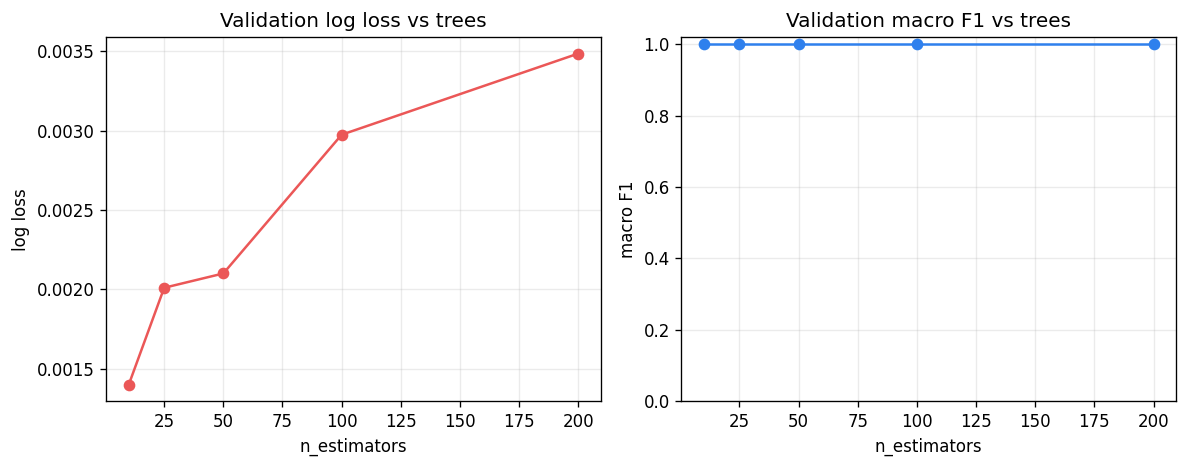


=== Posture classifier: validation ===
                 precision    recall  f1-score   support

  non_risk_bend       1.00      1.00      1.00        28
normal_activity       1.00      1.00      1.00        28
      safe_lift       1.00      1.00      1.00        14
     stoop_risk       1.00      1.00      1.00        14
 transit_ignore       1.00      1.00      1.00        14
     twist_risk       1.00      1.00      1.00        14

       accuracy                           1.00       112
      macro avg       1.00      1.00      1.00       112
   weighted avg       1.00      1.00      1.00       112



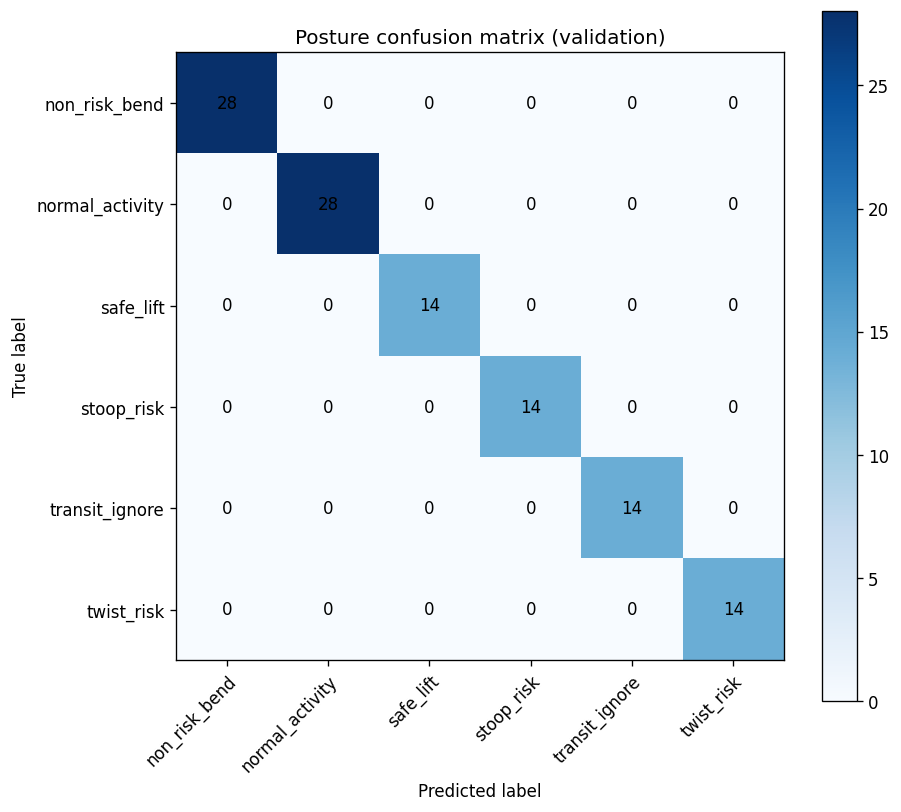


=== Posture classifier: validation by motion_phase ===

--- motion_phase=carry_walk support=20 ---
                 precision    recall  f1-score   support

  non_risk_bend       0.00      0.00      0.00         0
normal_activity       1.00      1.00      1.00        14
      safe_lift       1.00      1.00      1.00         2
     stoop_risk       1.00      1.00      1.00         2
 transit_ignore       0.00      0.00      0.00         0
     twist_risk       1.00      1.00      1.00         2

       accuracy                           1.00        20
      macro avg       0.67      0.67      0.67        20
   weighted avg       1.00      1.00      1.00        20


--- motion_phase=hold_still support=9 ---
                 precision    recall  f1-score   support

  non_risk_bend       0.00      0.00      0.00         0
normal_activity       0.00      0.00      0.00         0
      safe_lift       1.00      1.00      1.00         3
     stoop_risk       1.00      1.00      1.00         

,motion_phase,support,accuracy,macro_f1,weighted_f1
0,carry_walk,20,1.0,0.666667,1.0
1,hold_still,9,1.0,0.500000,1.0
2,idle,20,1.0,0.666667,1.0
3,lift_up,6,1.0,0.500000,1.0
4,place_down,6,1.0,0.500000,1.0
5,prepare_descend,20,1.0,0.666667,1.0
6,return_stand,17,1.0,0.666667,1.0
7,unknown,14,1.0,0.166667,1.0



=== Posture classifier: test ===
                 precision    recall  f1-score   support

  non_risk_bend       1.00      1.00      1.00        28
normal_activity       1.00      1.00      1.00        28
      safe_lift       1.00      1.00      1.00        14
     stoop_risk       1.00      1.00      1.00        14
 transit_ignore       1.00      1.00      1.00        14
     twist_risk       1.00      1.00      1.00        14

       accuracy                           1.00       112
      macro avg       1.00      1.00      1.00       112
   weighted avg       1.00      1.00      1.00       112



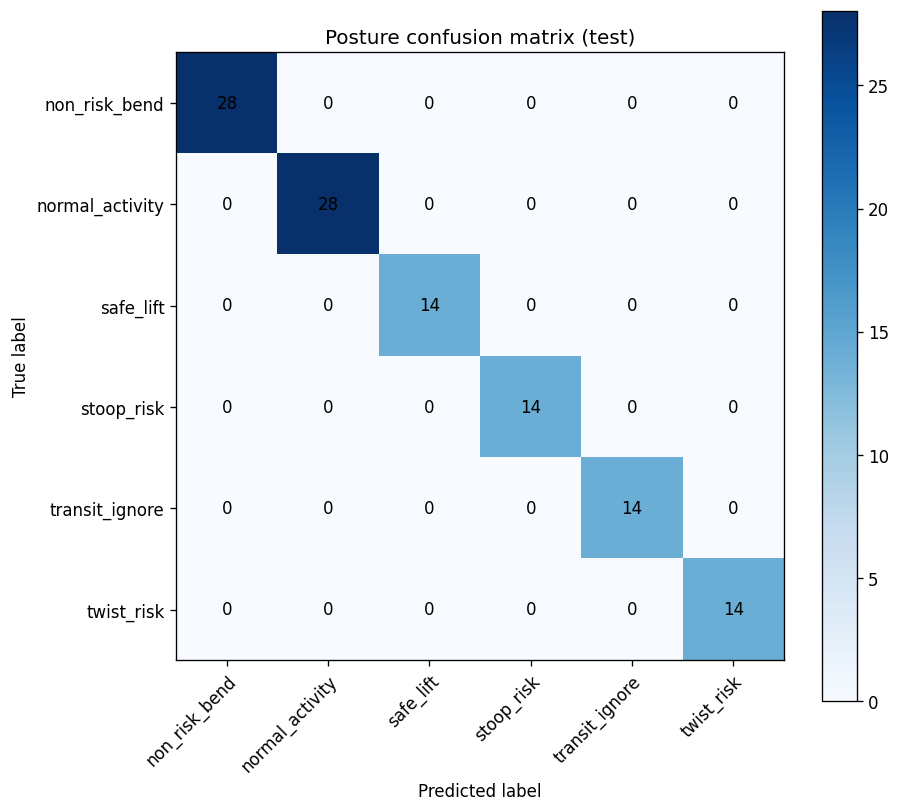


=== Posture classifier: test by motion_phase ===

--- motion_phase=carry_walk support=20 ---
                 precision    recall  f1-score   support

  non_risk_bend       0.00      0.00      0.00         0
normal_activity       1.00      1.00      1.00        14
      safe_lift       1.00      1.00      1.00         2
     stoop_risk       1.00      1.00      1.00         2
 transit_ignore       0.00      0.00      0.00         0
     twist_risk       1.00      1.00      1.00         2

       accuracy                           1.00        20
      macro avg       0.67      0.67      0.67        20
   weighted avg       1.00      1.00      1.00        20


--- motion_phase=hold_still support=9 ---
                 precision    recall  f1-score   support

  non_risk_bend       0.00      0.00      0.00         0
normal_activity       0.00      0.00      0.00         0
      safe_lift       1.00      1.00      1.00         3
     stoop_risk       1.00      1.00      1.00         3
 tra

,motion_phase,support,accuracy,macro_f1,weighted_f1
0,carry_walk,20,1.0,0.666667,1.0
1,hold_still,9,1.0,0.500000,1.0
2,idle,20,1.0,0.666667,1.0
3,lift_up,6,1.0,0.500000,1.0
4,place_down,6,1.0,0.500000,1.0
5,prepare_descend,20,1.0,0.666667,1.0
6,return_stand,17,1.0,0.666667,1.0
7,unknown,14,1.0,0.166667,1.0


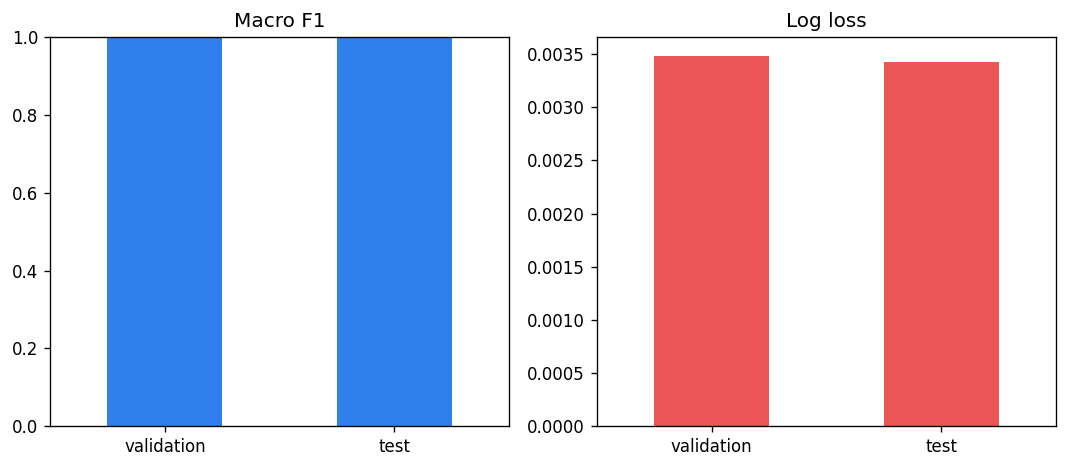

Saved posture classifier to artifacts_synthetic/filter_comparison/posture/raw/posture_classifier.joblib
Training posture model with filtered features...
Person-based split: train subjects=3, val=1, test=1


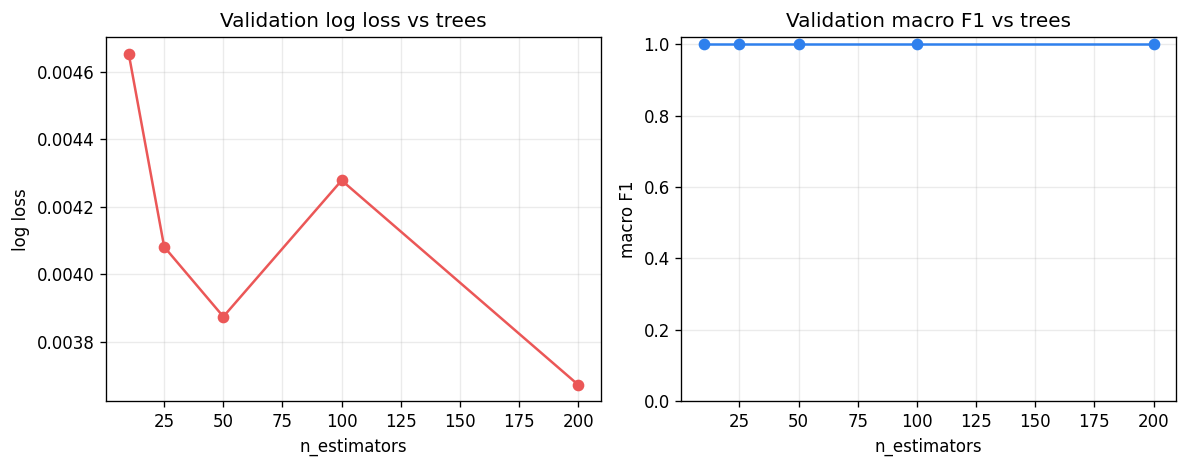


=== Posture classifier: validation ===
                 precision    recall  f1-score   support

  non_risk_bend       1.00      1.00      1.00        28
normal_activity       1.00      1.00      1.00        28
      safe_lift       1.00      1.00      1.00        14
     stoop_risk       1.00      1.00      1.00        14
 transit_ignore       1.00      1.00      1.00        14
     twist_risk       1.00      1.00      1.00        14

       accuracy                           1.00       112
      macro avg       1.00      1.00      1.00       112
   weighted avg       1.00      1.00      1.00       112



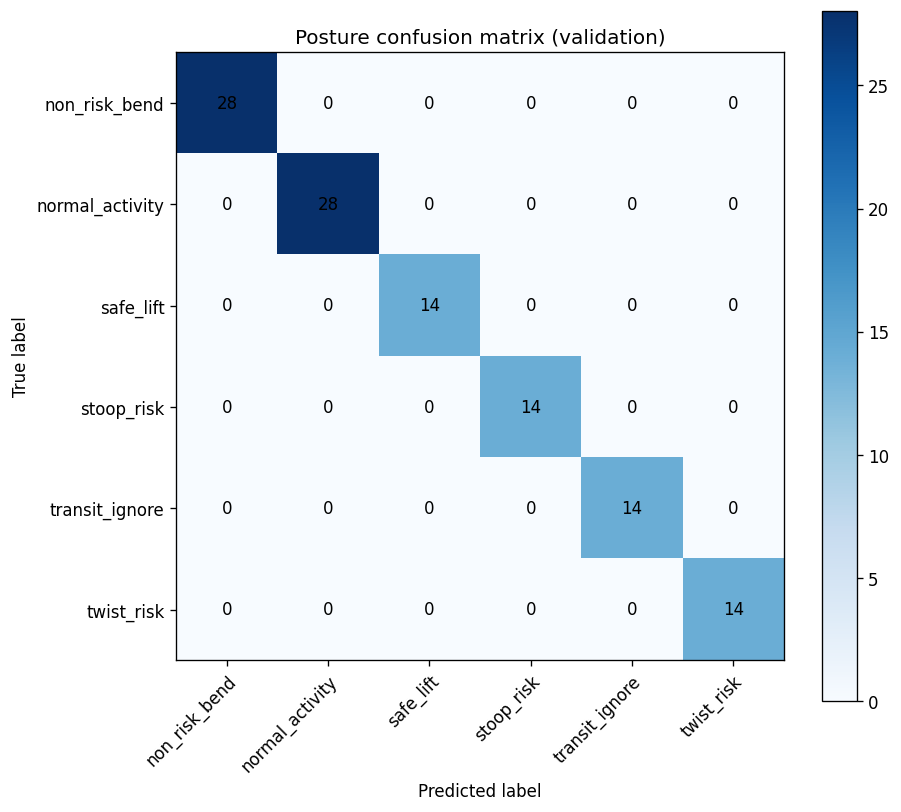


=== Posture classifier: validation by motion_phase ===

--- motion_phase=carry_walk support=20 ---
                 precision    recall  f1-score   support

  non_risk_bend       0.00      0.00      0.00         0
normal_activity       1.00      1.00      1.00        14
      safe_lift       1.00      1.00      1.00         2
     stoop_risk       1.00      1.00      1.00         2
 transit_ignore       0.00      0.00      0.00         0
     twist_risk       1.00      1.00      1.00         2

       accuracy                           1.00        20
      macro avg       0.67      0.67      0.67        20
   weighted avg       1.00      1.00      1.00        20


--- motion_phase=hold_still support=9 ---
                 precision    recall  f1-score   support

  non_risk_bend       0.00      0.00      0.00         0
normal_activity       0.00      0.00      0.00         0
      safe_lift       1.00      1.00      1.00         3
     stoop_risk       1.00      1.00      1.00         

,motion_phase,support,accuracy,macro_f1,weighted_f1
0,carry_walk,20,1.0,0.666667,1.0
1,hold_still,9,1.0,0.500000,1.0
2,idle,20,1.0,0.666667,1.0
3,lift_up,6,1.0,0.500000,1.0
4,place_down,6,1.0,0.500000,1.0
5,prepare_descend,20,1.0,0.666667,1.0
6,return_stand,17,1.0,0.666667,1.0
7,unknown,14,1.0,0.166667,1.0



=== Posture classifier: test ===
                 precision    recall  f1-score   support

  non_risk_bend       1.00      1.00      1.00        28
normal_activity       1.00      1.00      1.00        28
      safe_lift       1.00      1.00      1.00        14
     stoop_risk       1.00      1.00      1.00        14
 transit_ignore       1.00      1.00      1.00        14
     twist_risk       1.00      1.00      1.00        14

       accuracy                           1.00       112
      macro avg       1.00      1.00      1.00       112
   weighted avg       1.00      1.00      1.00       112



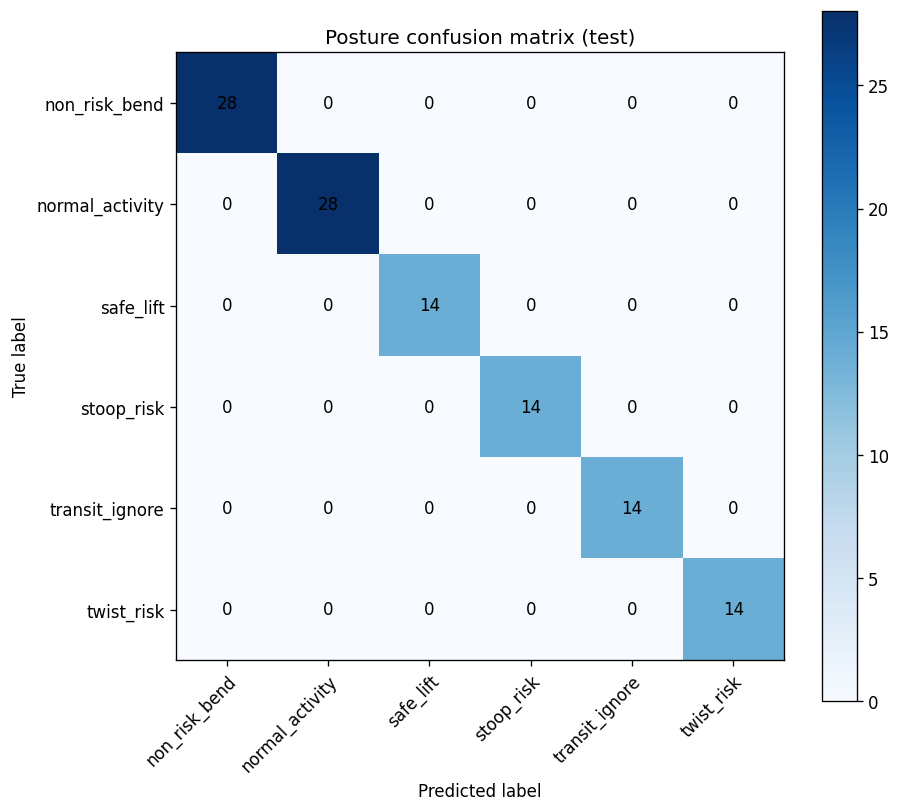


=== Posture classifier: test by motion_phase ===

--- motion_phase=carry_walk support=20 ---
                 precision    recall  f1-score   support

  non_risk_bend       0.00      0.00      0.00         0
normal_activity       1.00      1.00      1.00        14
      safe_lift       1.00      1.00      1.00         2
     stoop_risk       1.00      1.00      1.00         2
 transit_ignore       0.00      0.00      0.00         0
     twist_risk       1.00      1.00      1.00         2

       accuracy                           1.00        20
      macro avg       0.67      0.67      0.67        20
   weighted avg       1.00      1.00      1.00        20


--- motion_phase=hold_still support=9 ---
                 precision    recall  f1-score   support

  non_risk_bend       0.00      0.00      0.00         0
normal_activity       0.00      0.00      0.00         0
      safe_lift       1.00      1.00      1.00         3
     stoop_risk       1.00      1.00      1.00         3
 tra

,motion_phase,support,accuracy,macro_f1,weighted_f1
0,carry_walk,20,1.0,0.666667,1.0
1,hold_still,9,1.0,0.500000,1.0
2,idle,20,1.0,0.666667,1.0
3,lift_up,6,1.0,0.500000,1.0
4,place_down,6,1.0,0.500000,1.0
5,prepare_descend,20,1.0,0.666667,1.0
6,return_stand,17,1.0,0.666667,1.0
7,unknown,14,1.0,0.166667,1.0


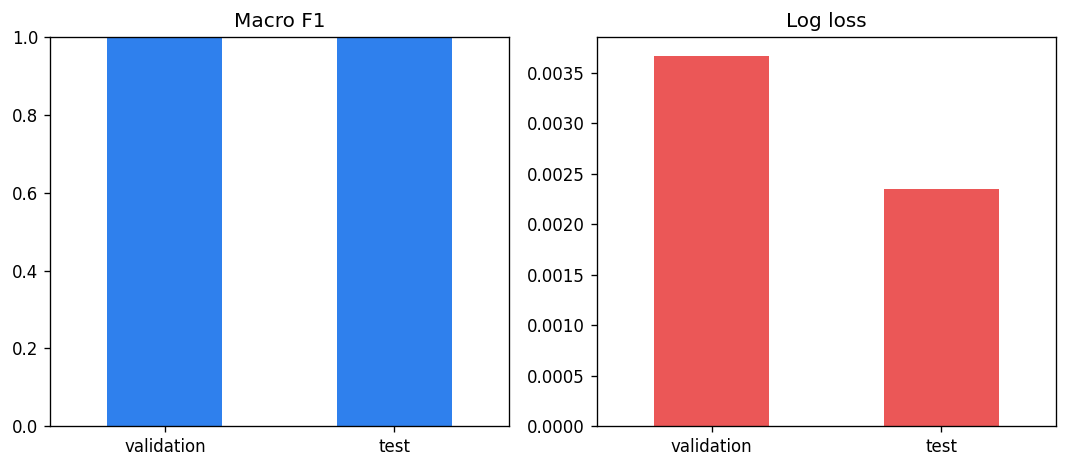

Saved posture classifier to artifacts_synthetic/filter_comparison/posture/filtered/posture_classifier.joblib


,variant,validation_macro_f1,validation_log_loss,test_macro_f1,test_log_loss
0,raw,1.0,0.003486,1.0,0.003426
1,filtered,1.0,0.003672,1.0,0.002345


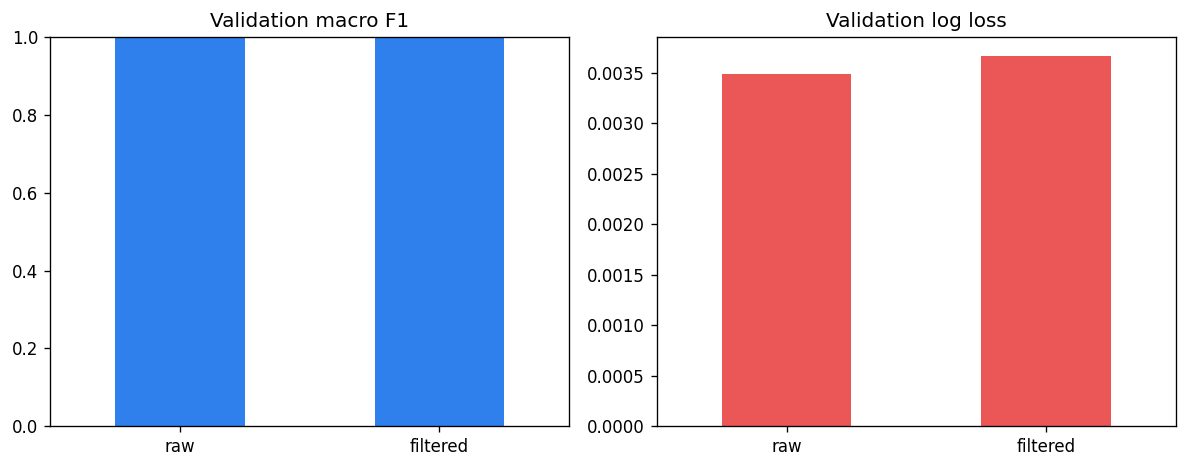

Training movement degradation proxy with raw features...

=== Movement degradation score by session_phase ===


,count,mean,std,min,25%,50%,75%,max
session_phase,,,,,,,,
fatigue_like,50.0,1.707903e+08,1.724327e+08,74252.724474,98779.393341,1.680686e+08,3.414371e+08,3.463395e+08
fresh_baseline,50.0,1.200000e+01,5.327667e+00,3.474295,8.029368,1.064053e+01,1.503328e+01,2.683812e+01
repeated_task,50.0,6.118581e+04,5.753639e+04,2951.112218,4279.442988,5.949249e+04,1.166700e+05,1.268301e+05



=== Movement degradation score by RPE weak label ===


,count,mean,std,min,25%,50%,75%,max
rpe_weak_label,,,,,,,,
fatigue_like,50.0,1.707903e+08,1.724327e+08,74252.724474,98779.393341,1.680686e+08,3.414371e+08,3.463395e+08
fresh,50.0,1.200000e+01,5.327667e+00,3.474295,8.029368,1.064053e+01,1.503328e+01,2.683812e+01
medium_fatigue,50.0,6.118581e+04,5.753639e+04,2951.112218,4279.442988,5.949249e+04,1.166700e+05,1.268301e+05


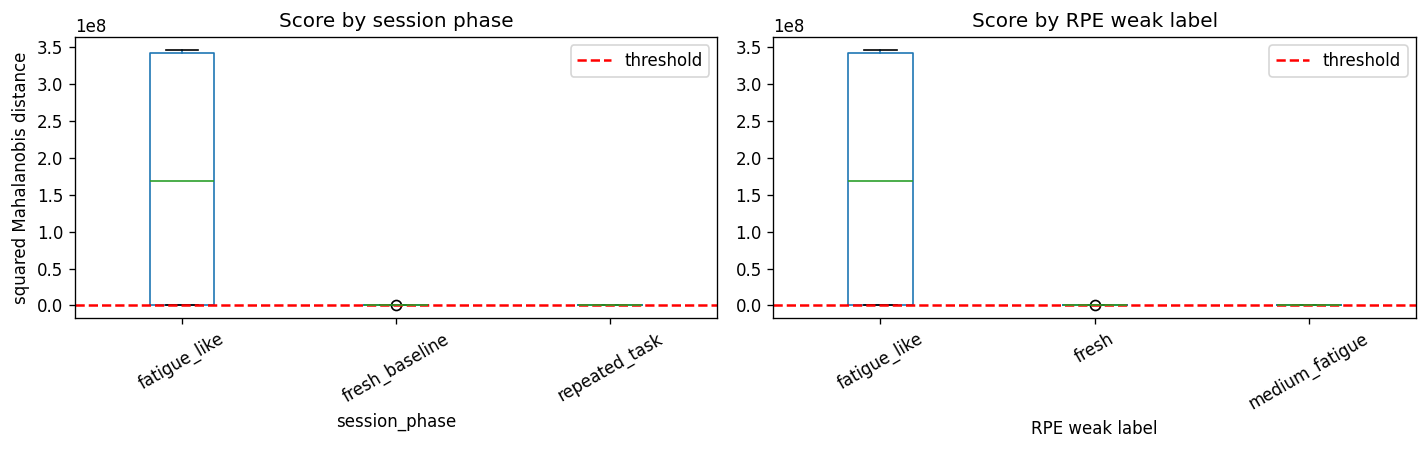

Saved movement degradation proxy to artifacts_synthetic/filter_comparison/movement_degradation/raw/movement_degradation_proxy.joblib
Training movement degradation proxy with filtered features...

=== Movement degradation score by session_phase ===


,count,mean,std,min,25%,50%,75%,max
session_phase,,,,,,,,
fatigue_like,50.0,8.095462e+07,8.168540e+07,76149.145443,95475.131719,7.917785e+07,1.619799e+08,1.651046e+08
fresh_baseline,50.0,1.200000e+01,5.891623e+00,2.306138,8.023009,1.151920e+01,1.676604e+01,2.450376e+01
repeated_task,50.0,5.685010e+04,5.406995e+04,2347.616696,3327.743599,5.467149e+04,1.085709e+05,1.188166e+05



=== Movement degradation score by RPE weak label ===


,count,mean,std,min,25%,50%,75%,max
rpe_weak_label,,,,,,,,
fatigue_like,50.0,8.095462e+07,8.168540e+07,76149.145443,95475.131719,7.917785e+07,1.619799e+08,1.651046e+08
fresh,50.0,1.200000e+01,5.891623e+00,2.306138,8.023009,1.151920e+01,1.676604e+01,2.450376e+01
medium_fatigue,50.0,5.685010e+04,5.406995e+04,2347.616696,3327.743599,5.467149e+04,1.085709e+05,1.188166e+05


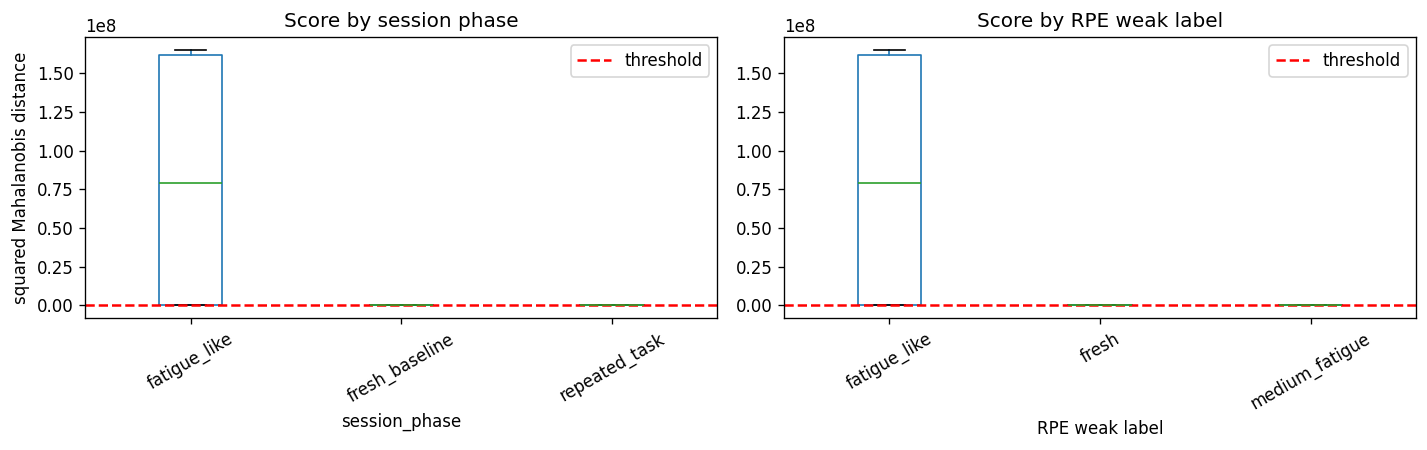

Saved movement degradation proxy to artifacts_synthetic/filter_comparison/movement_degradation/filtered/movement_degradation_proxy.joblib


,variant,session_phase,count,mean,median,std
0,raw,fatigue_like,50,1.707903e+08,1.680686e+08,1.724327e+08
1,raw,fresh_baseline,50,1.200000e+01,1.064053e+01,5.327667e+00
2,raw,repeated_task,50,6.118581e+04,5.949249e+04,5.753639e+04
3,filtered,fatigue_like,50,8.095462e+07,7.917785e+07,8.168540e+07
4,filtered,fresh_baseline,50,1.200000e+01,1.151920e+01,5.891623e+00
5,filtered,repeated_task,50,5.685010e+04,5.467149e+04,5.406995e+04


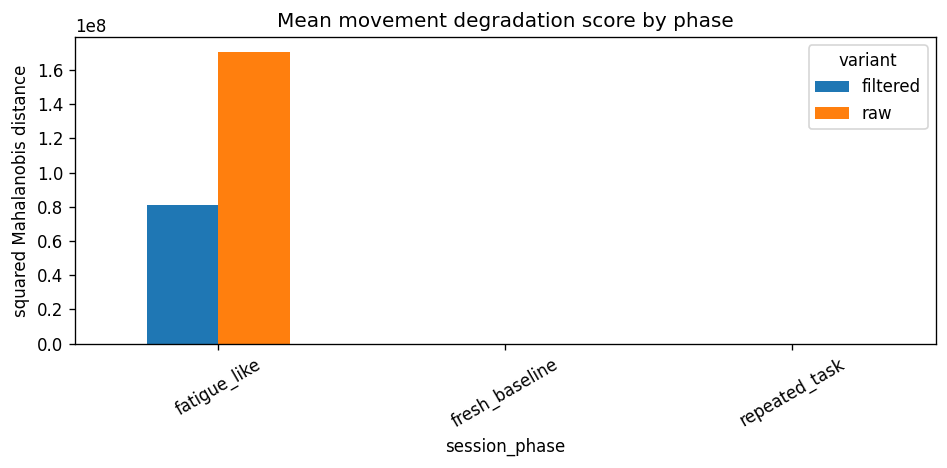

Saved comparison outputs under: /lustrefs/disk/home/ub097/achi/artifacts_synthetic/filter_comparison


In [62]:
ensure_dir(CONFIG.output_dir)

print("Loading data for raw-vs-filtered comparison...")
comparison_data = load_csv_folder(CONFIG.data_dir)

filter_comparison = run_filter_comparison_experiment(comparison_data, CONFIG.output_dir)
print("Saved comparison outputs under:", Path(CONFIG.output_dir, "filter_comparison").resolve())

## Run Training

Run the next cell after your CSV files are available under `CONFIG.data_dir`.

Loading CSV dataset...
Running raw-data EDA...
Rows: 24,000
Trials: 40
Subjects: 5
Saved EDA to artifacts_synthetic


/tmp/ipykernel_190836/3830508937.py:11: UserWarning: data/raw_synthetic/synthetic_s01.csv is missing optional columns: ['pitch_up', 'roll_up', 'yaw_up', 'pitch_low', 'roll_low', 'yaw_low']. Dependent features/metadata will be skipped or filled safely.
  warn_missing_optional_columns(df, str(path))
/tmp/ipykernel_190836/3830508937.py:11: UserWarning: data/raw_synthetic/synthetic_s02.csv is missing optional columns: ['pitch_up', 'roll_up', 'yaw_up', 'pitch_low', 'roll_low', 'yaw_low']. Dependent features/metadata will be skipped or filled safely.
  warn_missing_optional_columns(df, str(path))
/tmp/ipykernel_190836/3830508937.py:11: UserWarning: data/raw_synthetic/synthetic_s03.csv is missing optional columns: ['pitch_up', 'roll_up', 'yaw_up', 'pitch_low', 'roll_low', 'yaw_low']. Dependent features/metadata will be skipped or filled safely.
  warn_missing_optional_columns(df, str(path))
/tmp/ipykernel_190836/3830508937.py:11: UserWarning: data/raw_synthetic/synthetic_s04.csv is missing op

,column,null_count,null_pct,dtype
16,acc_low_x,0,0.0,float64
17,acc_low_y,0,0.0,float64
18,acc_low_z,0,0.0,float64
10,acc_up_x,0,0.0,float64
11,acc_up_y,0,0.0,float64
12,acc_up_z,0,0.0,float64
19,gyro_low_x,0,0.0,float64
20,gyro_low_y,0,0.0,float64
21,gyro_low_z,0,0.0,float64
13,gyro_up_x,0,0.0,float64


No null values found.


,trial_id,subject_id,label,session_phase,motion_phase,motion_phase_purity,label_quality,rows,duration_s,approx_hz,source_file
count,40,40,40,40,40,40.000000,40,40.0,40.00,40.0,40
unique,40,5,8,4,4,NaN,1,NaN,NaN,NaN,5
top,synthetic_s01_01_safe_lift_motion,synthetic_s01,safe_lift_motion,fresh_baseline,prepare_descend,NaN,clean,NaN,NaN,NaN,data/raw_synthetic/synthetic_s01.csv
freq,1,8,5,10,25,NaN,40,NaN,NaN,NaN,8
mean,NaN,NaN,NaN,NaN,NaN,0.553750,NaN,600.0,11.98,50.0,NaN
std,NaN,NaN,NaN,NaN,NaN,0.376985,NaN,0.0,0.00,0.0,NaN
min,NaN,NaN,NaN,NaN,NaN,0.143333,NaN,600.0,11.98,50.0,NaN
25%,NaN,NaN,NaN,NaN,NaN,0.143333,NaN,600.0,11.98,50.0,NaN
50%,NaN,NaN,NaN,NaN,NaN,0.500000,NaN,600.0,11.98,50.0,NaN
75%,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,600.0,11.98,50.0,NaN


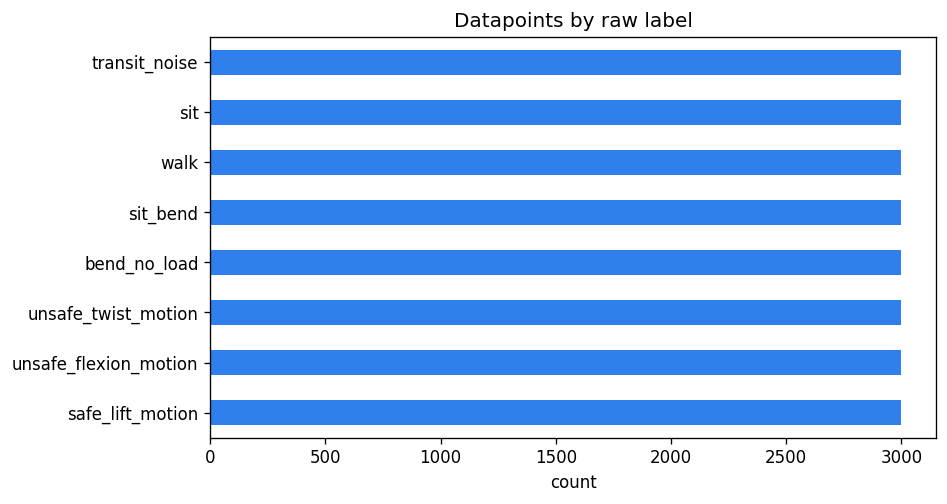

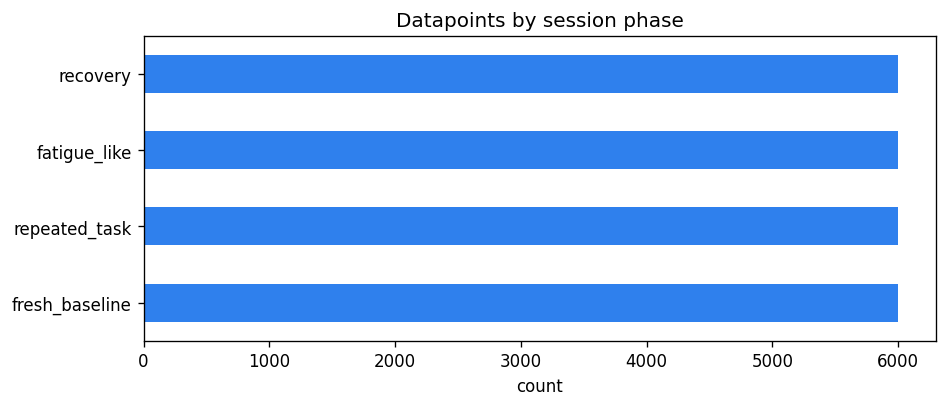

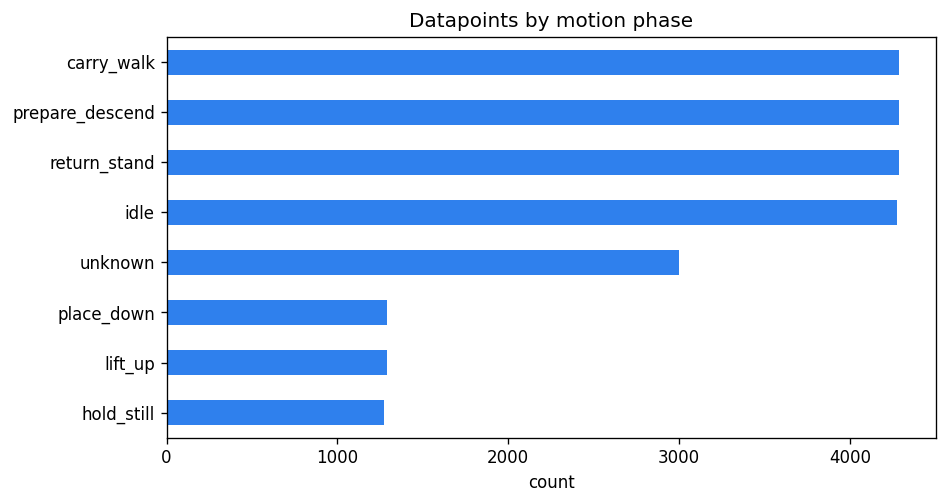

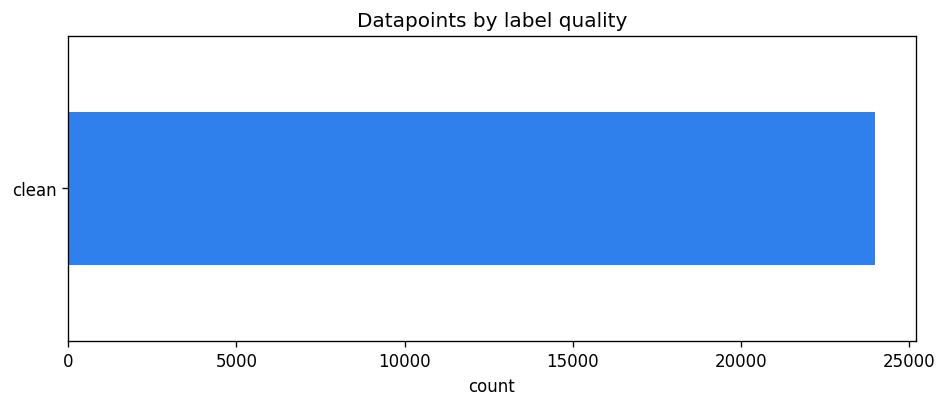

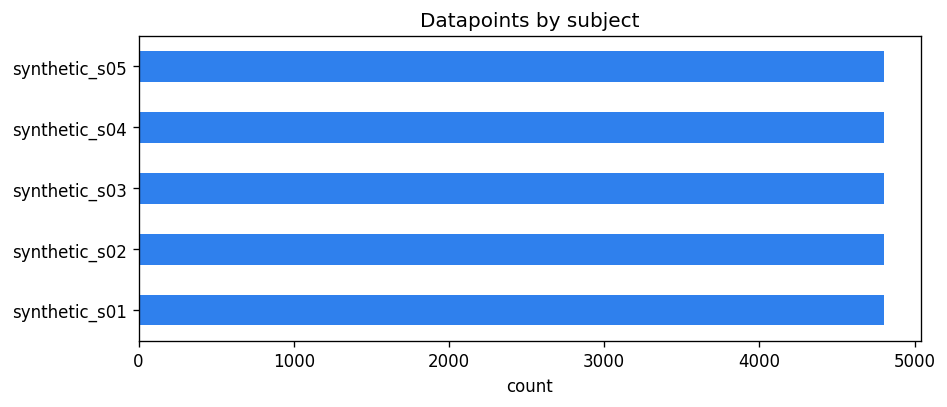

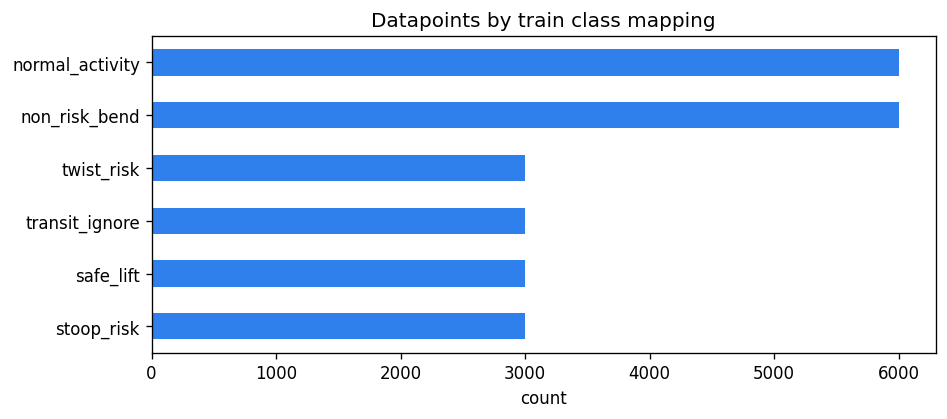

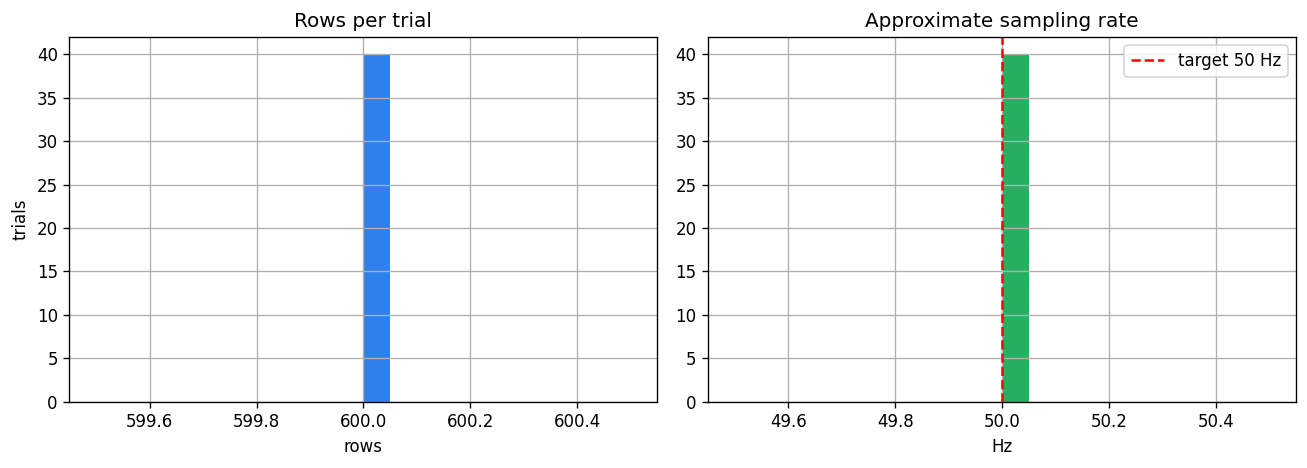

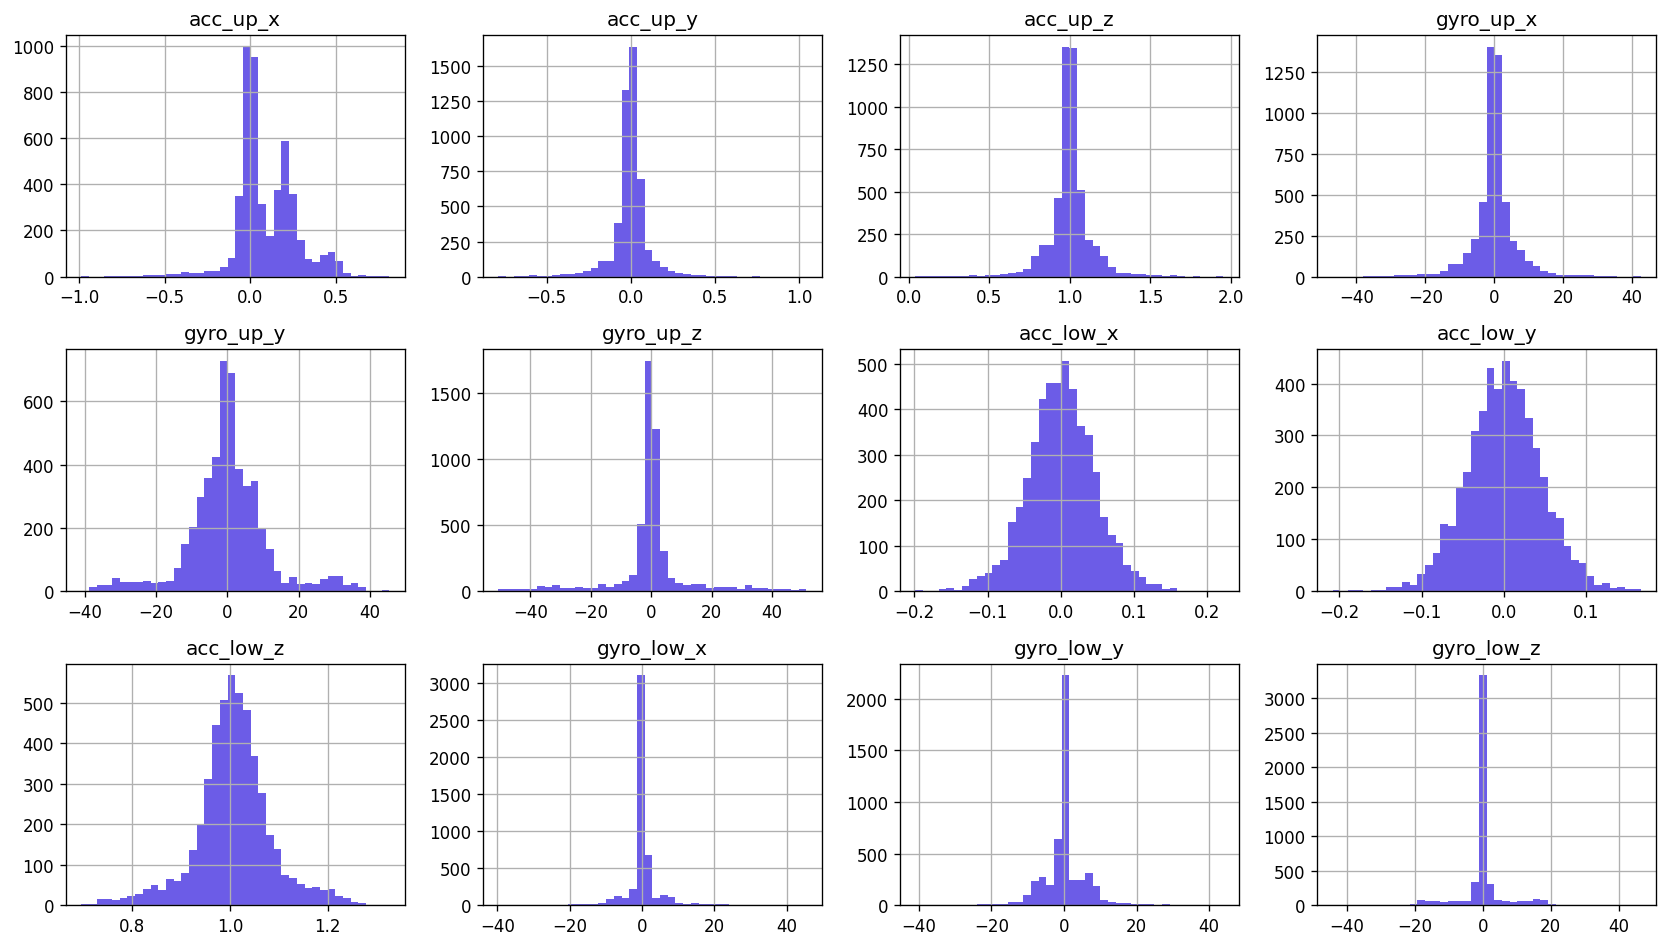

Running movement degradation FFT/supporting spectral EDA before model training...


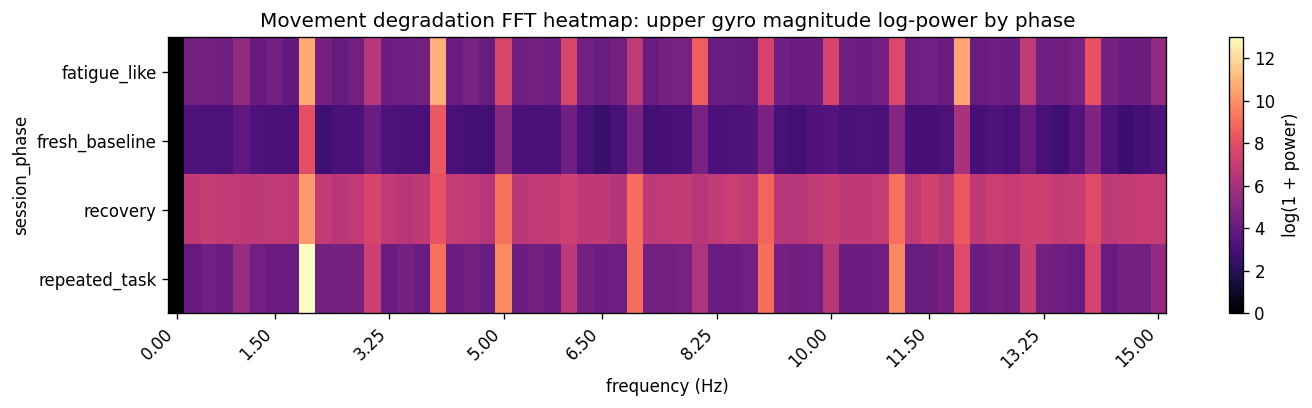

/tmp/ipykernel_190836/1938104220.py:193: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(values, labels=phases, showfliers=False)
/tmp/ipykernel_190836/1938104220.py:193: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(values, labels=phases, showfliers=False)
/tmp/ipykernel_190836/1938104220.py:193: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(values, labels=phases, showfliers=False)


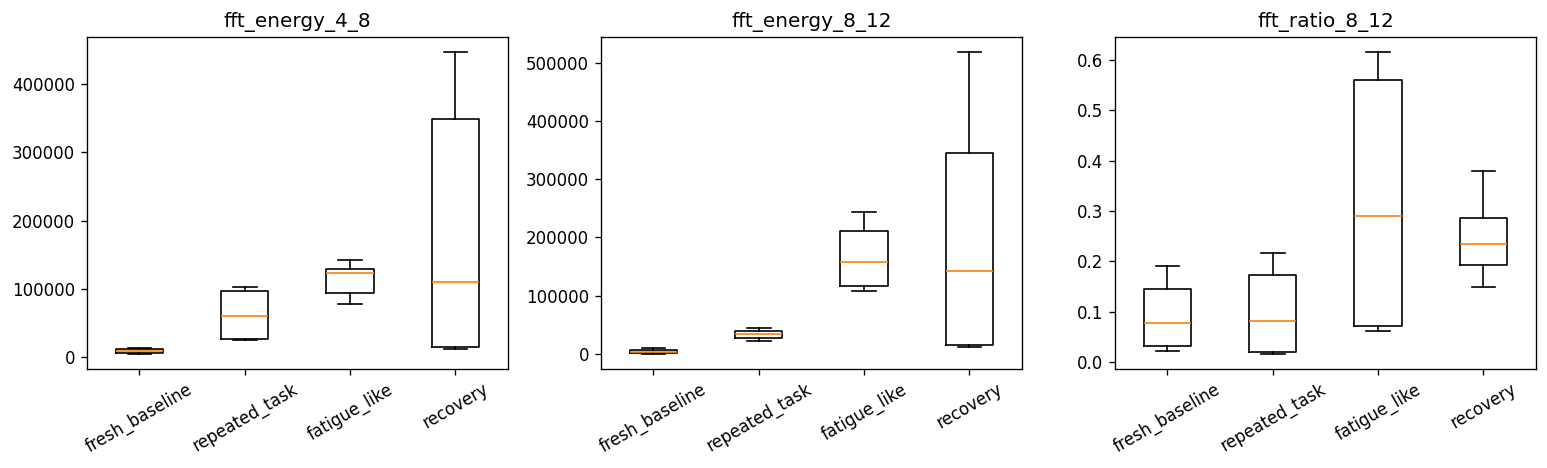

Creating posture windows...
Posture windows: 560
Creating movement degradation windows...
Movement degradation windows: 200
Running feature-level EDA before model training...


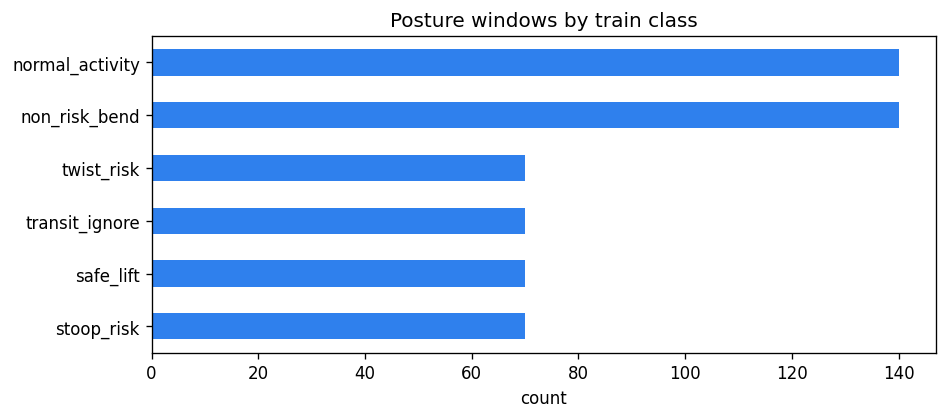

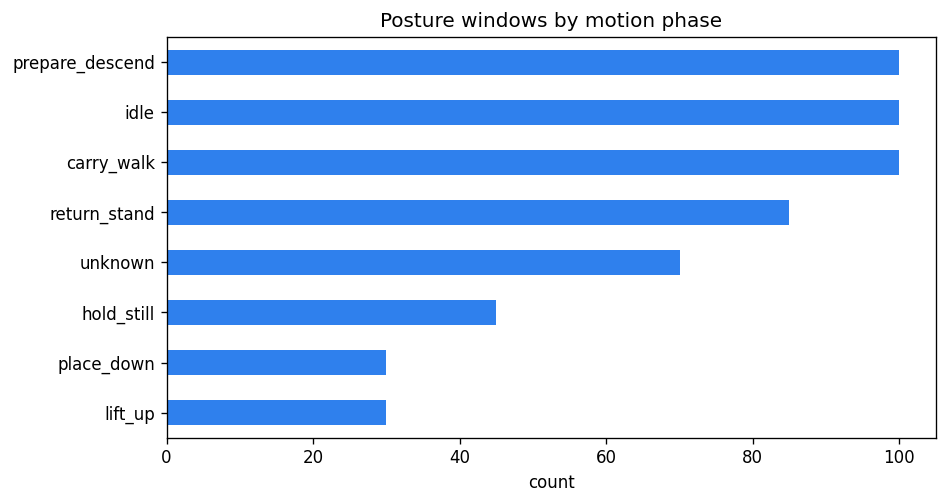

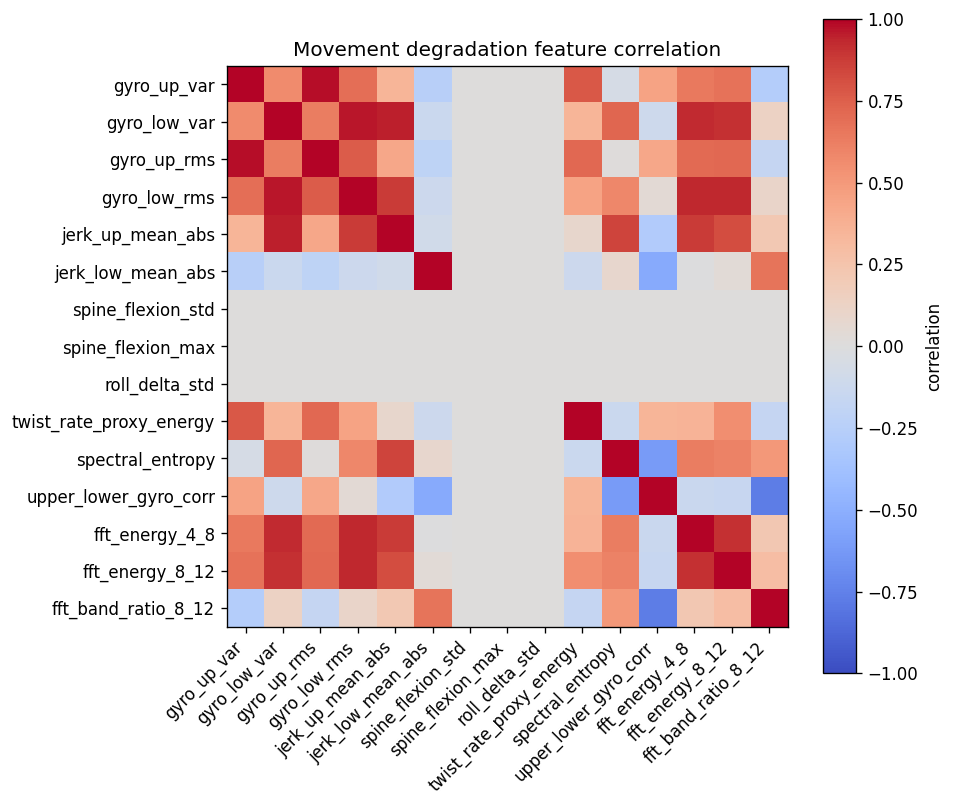

,trial_id,subject_id,label,risk_label,session_phase,rpe,load_level,label_quality,motion_phase,motion_phase_purity,window_start_ms,window_end_ms,acc_up_x_mean,acc_up_x_std,acc_up_x_min,acc_up_x_max,acc_up_y_mean,acc_up_y_std,acc_up_y_min,acc_up_y_max,acc_up_z_mean,acc_up_z_std,acc_up_z_min,acc_up_z_max,gyro_up_x_mean,gyro_up_x_std,gyro_up_x_min,gyro_up_x_max,gyro_up_y_mean,gyro_up_y_std,gyro_up_y_min,gyro_up_y_max,gyro_up_z_mean,gyro_up_z_std,gyro_up_z_min,gyro_up_z_max,acc_low_x_mean,acc_low_x_std,acc_low_x_min,acc_low_x_max,acc_low_y_mean,acc_low_y_std,acc_low_y_min,acc_low_y_max,acc_low_z_mean,acc_low_z_std,acc_low_z_min,acc_low_z_max,gyro_low_x_mean,gyro_low_x_std,gyro_low_x_min,gyro_low_x_max,gyro_low_y_mean,gyro_low_y_std,gyro_low_y_min,gyro_low_y_max,gyro_low_z_mean,gyro_low_z_std,gyro_low_z_min,gyro_low_z_max,acc_up_mag_mean,acc_up_mag_std,jerk_up_max,jerk_up_mean,gyro_up_mag_mean,gyro_up_mag_std,gyro_up_energy,acc_low_mag_mean,acc_low_mag_std,jerk_low_max,jerk_low_mean,gyro_low_mag_mean,gyro_low_mag_std,gyro_low_energy,twist_rate_proxy_mean,twist_rate_proxy_max,twist_rate_proxy_energy,upper_lower_gyro_corr
0,synthetic_s01_01_safe_lift_motion,synthetic_s01,safe_lift_motion,safe_lift,fresh_baseline,2,synthetic,clean,idle,1.000000,0,1480,0.000910,0.031530,-0.078041,0.085666,-0.005407,0.041446,-0.102590,0.101973,1.038071,0.124553,0.788758,1.229958,0.063977,1.220520,-2.954266,2.757807,2.746511,8.245593,-13.458283,13.926292,-0.215281,1.349126,-3.588774,3.164759,-0.003812,0.035978,-0.084308,0.062353,-0.006365,0.041593,-0.094888,0.104145,1.032086,0.103231,0.826882,1.236393,0.014931,0.738276,-1.484817,1.829960,1.604223,5.385053,-8.630009,9.298492,-0.109408,0.756281,-2.165070,1.955280,1.039418,0.124325,7.177264,2.113466,8.126316,3.585575,78.893365,1.033586,0.103140,6.737331,2.149286,5.171186,2.441387,32.701531,1.207302,4.400884,2.380232,0.891906
1,synthetic_s01_01_safe_lift_motion,synthetic_s01,safe_lift_motion,safe_lift,fresh_baseline,2,synthetic,clean,idle,0.626667,760,2240,-0.004954,0.030428,-0.069093,0.059798,-0.003873,0.040122,-0.102590,0.095304,0.997485,0.135431,0.762853,1.208643,-0.059231,1.227442,-2.954266,2.941163,-0.022726,8.705525,-13.836675,13.543968,-0.083541,1.296904,-3.200850,3.164759,-0.008693,0.038920,-0.116686,0.072357,0.004041,0.038084,-0.087702,0.104145,1.004194,0.109128,0.820383,1.236393,-0.073801,0.729220,-1.883640,1.527032,-0.008375,5.750918,-8.639920,9.298492,-0.073723,0.837520,-2.165070,1.955280,0.998797,0.135272,7.678145,2.635445,8.116559,3.620389,78.985746,1.005751,0.108795,6.377855,2.198117,5.367496,2.346740,34.317208,1.267725,4.400884,2.644487,0.908700
2,synthetic_s01_01_safe_lift_motion,synthetic_s01,safe_lift_motion,safe_lift,fresh_baseline,2,synthetic,clean,prepare_descend,0.880000,1520,3000,-0.005528,0.036442,-0.085282,0.116554,-0.006049,0.038604,-0.092814,0.071904,0.958595,0.124692,0.762853,1.250261,0.011551,1.253046,-2.958698,2.941163,-2.609967,8.239266,-15.114079,13.517951,0.064935,1.237167,-3.200850,2.976966,-0.013463,0.044176,-0.121905,0.080039,0.009613,0.037494,-0.087702,0.088426,0.976402,0.099679,0.820383,1.202160,-0.075782,0.722335,-1.883640,1.527032,-1.681185,5.512675,-9.525983,9.019969,-0.007631,0.831450,-1.853943,1.465040,0.960159,0.124230,7.678145,2.710874,8.052622,3.599689,77.802487,0.978262,0.099654,6.581006,2.157282,5.359196,2.390369,34.434851,1.216676,3.846023,2.183089,0.892940
3,synthetic_s01_01_safe_lift_motion,synthetic_s01,safe_lift_motion,safe_lift,fresh_baseline,2,synthetic,clean,prepare_descend,0.760000,2280,3760,0.000824,0.040329,-0.085282,0.116554,0.002323,0.041357,-0.091230,0.081950,0.997163,0.132649,0.777937,1.250261,0.064631,1.291555,-2.958698,2.924263,-0.417830,8.507452,-15.114079,13.187430,-0.002574,1.228883,-2.518636,2.583067,-0.013927,0.038835,-0.121905,0.080039,0.008032,0.040523,-0.083968,0.090920,0.997369,0.103230,0.805794,1.189160,0.035180,0.714341,-1.767956,1.991403,-0.223743,5.740115,-9.525983,9.275611,0.023258,0.858150,-1.853943,1.656866,0.998882,0.132318,9.2

,trial_id,subject_id,label,risk_label,session_phase,rpe,load_level,label_quality,motion_phase,motion_phase_purity,window_start_ms,window_end_ms,gyro_up_var,gyro_low_var,gyro_up_rms,gyro_low_rms,jerk_up_mean_abs,jerk_low_mean_abs,spine_flexion_std,spine_flexion_max,roll_delta_std,twist_rate_proxy_energy,spectral_entropy,upper_lower_gyro_corr,fft_energy_4_8,fft_energy_8_12,fft_band_ratio_8_12
0,synthetic_s01_01_safe_lift_motion,synthetic_s01,safe_lift_motion,safe_lift,fresh_baseline,2,synthetic,clean,prepare_descend,0.430,0,3980,12.578672,5.844437,8.817885,5.818019,2.518814,2.120900,0.0,0.0,0.0,2.358723,0.168664,0.885902,11174.018048,7630.935377,0.030406
1,synthetic_s01_01_safe_lift_motion,synthetic_s01,safe_lift_motion,safe_lift,fresh_baseline,2,synthetic,clean,lift_up,0.430,2000,5980,12.550402,5.681350,8.821482,5.854897,2.601890,2.194825,0.0,0.0,0.0,2.253512,0.170813,0.882903,13024.901644,6606.353035,0.026410
2,synthetic_s01_01_safe_lift_motion,synthetic_s01,safe_lift_motion,safe_lift,fresh_baseline,2,synthetic,clean,hold_still,0.425,4000,7980,12.502115,5.886081,8.798118,5.917533,2.404411,2.166308,0.0,0.0,0.0,2.126344,0.168111,0.894096,13169.468705,5715.294597,0.022925
3,synthetic_s01_01_safe_lift_motion,synthetic_s01,safe_lift_motion,safe_lift,fresh_baseline,2,synthetic,clean,carry_walk,0.430,6000,9980,12.434187,6.043436,8.800291,5.882982,2.489274,2.137834,0.0,0.0,0.0,2.155060,0.159913,0.890327,9858.076752,6461.364344,0.026039
4,synthetic_s01_01_safe_lift_motion,synthetic_s01,safe_lift_motion,safe_lift,fresh_baseline,2,synthetic,clean,place_down,0.430,8000,11980,13.019154,5.521933,8.859719,5.777833,2.540164,2.362412,0.0,0.0,0.0,1.948209,0.175415,0.883399,11286.861600,9855.063563,0.037929


Training posture classifier...
Person-based split: train subjects=3, val=1, test=1


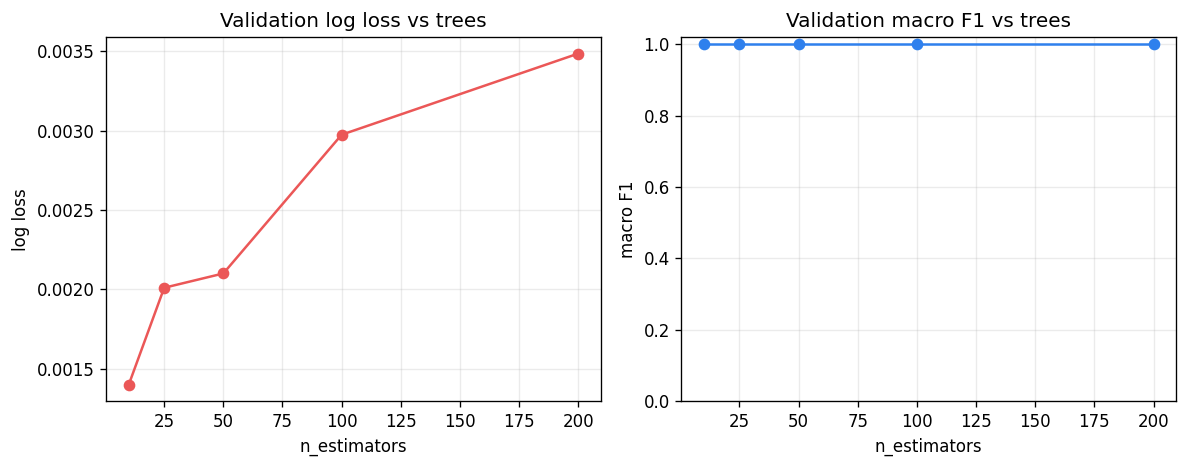


=== Posture classifier: validation ===
                 precision    recall  f1-score   support

  non_risk_bend       1.00      1.00      1.00        28
normal_activity       1.00      1.00      1.00        28
      safe_lift       1.00      1.00      1.00        14
     stoop_risk       1.00      1.00      1.00        14
 transit_ignore       1.00      1.00      1.00        14
     twist_risk       1.00      1.00      1.00        14

       accuracy                           1.00       112
      macro avg       1.00      1.00      1.00       112
   weighted avg       1.00      1.00      1.00       112



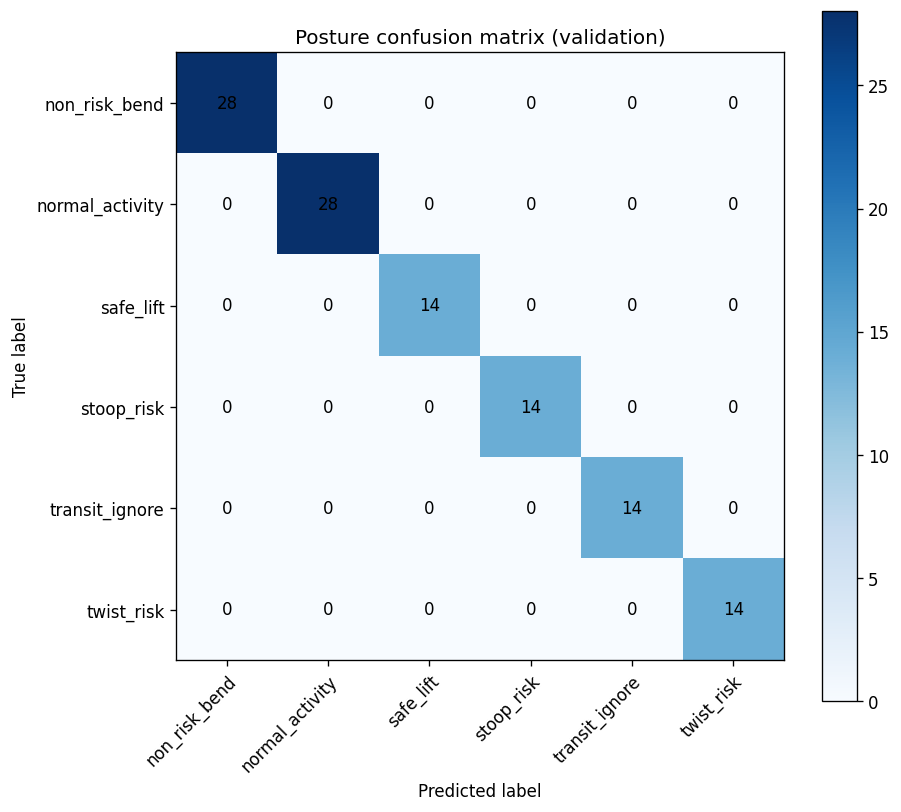


=== Posture classifier: validation by motion_phase ===

--- motion_phase=carry_walk support=20 ---
                 precision    recall  f1-score   support

  non_risk_bend       0.00      0.00      0.00         0
normal_activity       1.00      1.00      1.00        14
      safe_lift       1.00      1.00      1.00         2
     stoop_risk       1.00      1.00      1.00         2
 transit_ignore       0.00      0.00      0.00         0
     twist_risk       1.00      1.00      1.00         2

       accuracy                           1.00        20
      macro avg       0.67      0.67      0.67        20
   weighted avg       1.00      1.00      1.00        20


--- motion_phase=hold_still support=9 ---
                 precision    recall  f1-score   support

  non_risk_bend       0.00      0.00      0.00         0
normal_activity       0.00      0.00      0.00         0
      safe_lift       1.00      1.00      1.00         3
     stoop_risk       1.00      1.00      1.00         

,motion_phase,support,accuracy,macro_f1,weighted_f1
0,carry_walk,20,1.0,0.666667,1.0
1,hold_still,9,1.0,0.500000,1.0
2,idle,20,1.0,0.666667,1.0
3,lift_up,6,1.0,0.500000,1.0
4,place_down,6,1.0,0.500000,1.0
5,prepare_descend,20,1.0,0.666667,1.0
6,return_stand,17,1.0,0.666667,1.0
7,unknown,14,1.0,0.166667,1.0



=== Posture classifier: test ===
                 precision    recall  f1-score   support

  non_risk_bend       1.00      1.00      1.00        28
normal_activity       1.00      1.00      1.00        28
      safe_lift       1.00      1.00      1.00        14
     stoop_risk       1.00      1.00      1.00        14
 transit_ignore       1.00      1.00      1.00        14
     twist_risk       1.00      1.00      1.00        14

       accuracy                           1.00       112
      macro avg       1.00      1.00      1.00       112
   weighted avg       1.00      1.00      1.00       112



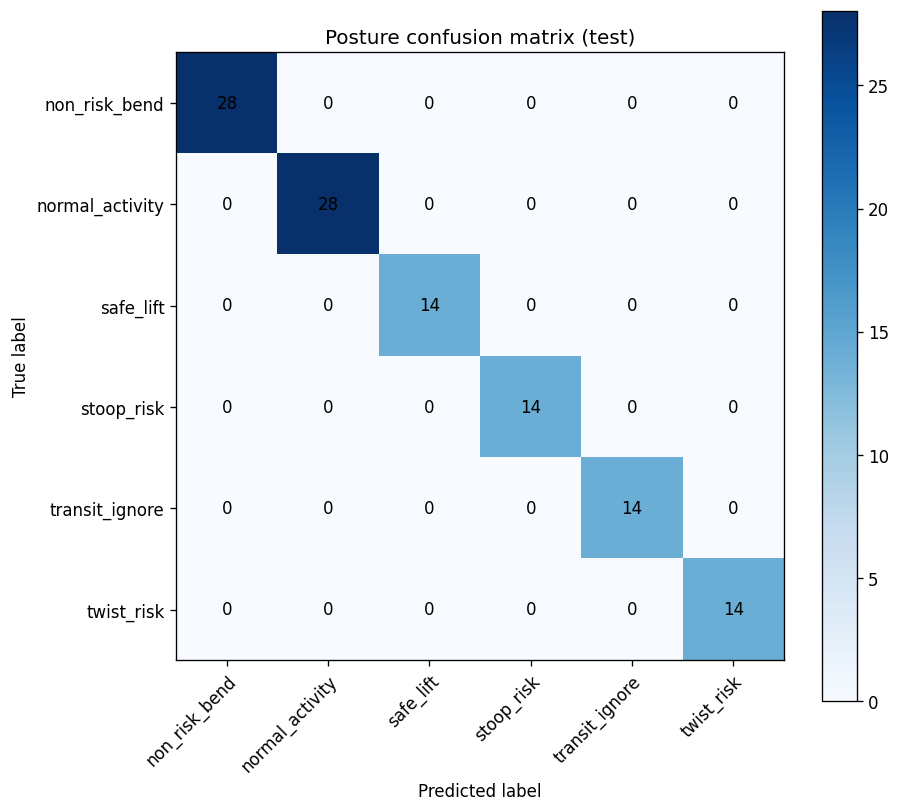


=== Posture classifier: test by motion_phase ===

--- motion_phase=carry_walk support=20 ---
                 precision    recall  f1-score   support

  non_risk_bend       0.00      0.00      0.00         0
normal_activity       1.00      1.00      1.00        14
      safe_lift       1.00      1.00      1.00         2
     stoop_risk       1.00      1.00      1.00         2
 transit_ignore       0.00      0.00      0.00         0
     twist_risk       1.00      1.00      1.00         2

       accuracy                           1.00        20
      macro avg       0.67      0.67      0.67        20
   weighted avg       1.00      1.00      1.00        20


--- motion_phase=hold_still support=9 ---
                 precision    recall  f1-score   support

  non_risk_bend       0.00      0.00      0.00         0
normal_activity       0.00      0.00      0.00         0
      safe_lift       1.00      1.00      1.00         3
     stoop_risk       1.00      1.00      1.00         3
 tra

,motion_phase,support,accuracy,macro_f1,weighted_f1
0,carry_walk,20,1.0,0.666667,1.0
1,hold_still,9,1.0,0.500000,1.0
2,idle,20,1.0,0.666667,1.0
3,lift_up,6,1.0,0.500000,1.0
4,place_down,6,1.0,0.500000,1.0
5,prepare_descend,20,1.0,0.666667,1.0
6,return_stand,17,1.0,0.666667,1.0
7,unknown,14,1.0,0.166667,1.0


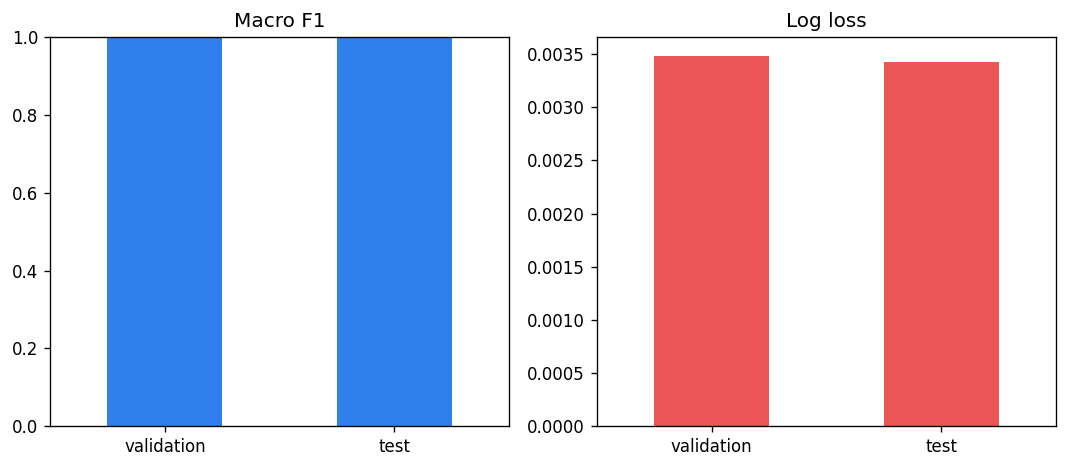

Saved posture classifier to artifacts_synthetic/posture_classifier.joblib
Training Gaussian movement degradation / fatigue proxy...

=== Movement degradation score by session_phase ===


,count,mean,std,min,25%,50%,75%,max
session_phase,,,,,,,,
fatigue_like,50.0,1.707903e+08,1.724327e+08,74252.724474,98779.393341,1.680686e+08,3.414371e+08,3.463395e+08
fresh_baseline,50.0,1.200000e+01,5.327667e+00,3.474295,8.029368,1.064053e+01,1.503328e+01,2.683812e+01
repeated_task,50.0,6.118581e+04,5.753639e+04,2951.112218,4279.442988,5.949249e+04,1.166700e+05,1.268301e+05



=== Movement degradation score by RPE weak label ===


,count,mean,std,min,25%,50%,75%,max
rpe_weak_label,,,,,,,,
fatigue_like,50.0,1.707903e+08,1.724327e+08,74252.724474,98779.393341,1.680686e+08,3.414371e+08,3.463395e+08
fresh,50.0,1.200000e+01,5.327667e+00,3.474295,8.029368,1.064053e+01,1.503328e+01,2.683812e+01
medium_fatigue,50.0,6.118581e+04,5.753639e+04,2951.112218,4279.442988,5.949249e+04,1.166700e+05,1.268301e+05


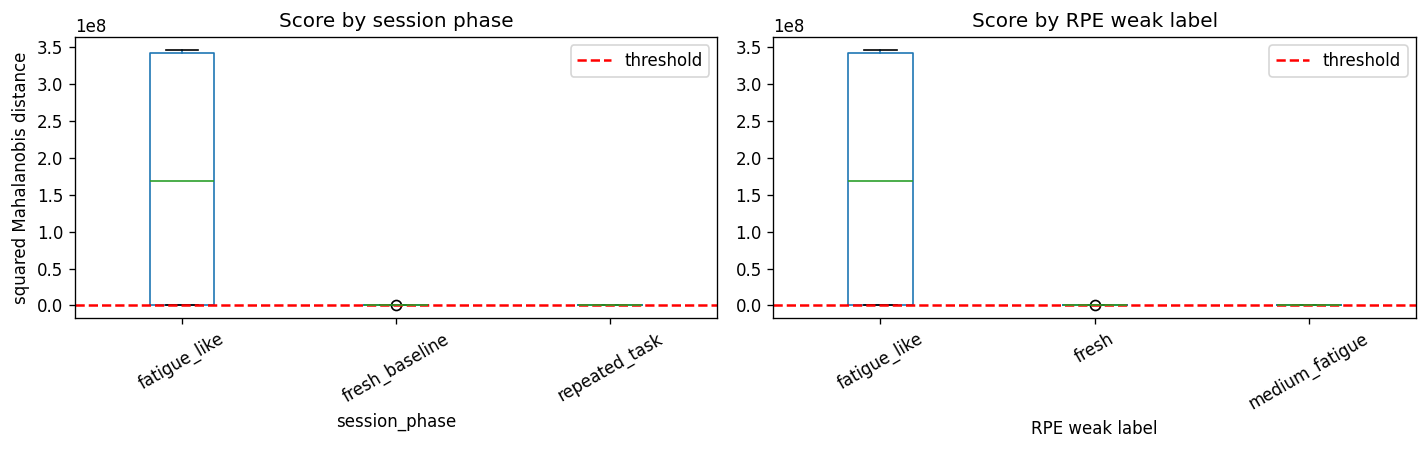

Saved movement degradation proxy to artifacts_synthetic/movement_degradation_proxy.joblib
Done. Artifacts saved under: /lustrefs/disk/home/ub097/achi/artifacts_synthetic


In [63]:
ensure_dir(CONFIG.output_dir)

print("Loading CSV dataset...")
data = load_csv_folder(CONFIG.data_dir)

print("Running raw-data EDA...")
eda_summary = run_eda(data, CONFIG.output_dir)
raw_eda = plot_raw_data_eda(data, CONFIG.output_dir)

print("Running movement degradation FFT/supporting spectral EDA before model training...")
fatigue_fft_eda = plot_fatigue_fft_eda(data, CONFIG.output_dir)

print("Creating posture windows...")
posture_windows = make_windows(data, CONFIG.posture_window_sec, CONFIG.posture_overlap, CONFIG.sampling_hz)
posture_features = build_feature_table(posture_windows, extract_posture_features, CONFIG.sampling_hz)
posture_features.to_csv(Path(CONFIG.output_dir) / "posture_features.csv", index=False)
print(f"Posture windows: {len(posture_features):,}")

print("Creating movement degradation windows...")
fatigue_windows = make_windows(data, CONFIG.fatigue_window_sec, CONFIG.fatigue_overlap, CONFIG.sampling_hz)
fatigue_features = build_feature_table(fatigue_windows, extract_fatigue_features, CONFIG.sampling_hz)
fatigue_features.to_csv(Path(CONFIG.output_dir) / "movement_degradation_features.csv", index=False)
print(f"Movement degradation windows: {len(fatigue_features):,}")

print("Running feature-level EDA before model training...")
plot_feature_eda(posture_features, fatigue_features, CONFIG.output_dir)

display(posture_features.head())
display(fatigue_features.head())

print("Training posture classifier...")
posture_result = train_posture_classifier(posture_features, CONFIG.output_dir)

print("Training Gaussian movement degradation / fatigue proxy...")
fatigue_result = train_movement_degradation_model(fatigue_features, CONFIG.output_dir)

print("Done. Artifacts saved under:", Path(CONFIG.output_dir).resolve())

## Package Artifacts

Use this after training if you want a zip containing models, reports, plots, and feature CSVs.

In [64]:
import shutil

zip_path = shutil.make_archive("sati_clip_artifacts", "zip", CONFIG.output_dir)
print(zip_path)

try:
    from google.colab import files
    files.download(zip_path)
except Exception:
    print("Download helper is only available in Colab. The zip file was still created locally in the runtime.")

/lustrefs/disk/home/ub097/achi/sati_clip_artifacts.zip
Download helper is only available in Colab. The zip file was still created locally in the runtime.
